# 사용할 코드만 정리

In [1]:
# 도구 불러오기
import pandas as pd
import numpy as np
import glob
import os
import re
import ast
from glob import glob
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import platform
import matplotlib.font_manager as fm

# 판다스 출력 제한 해제 
pd.set_option('display.max_rows', 100) # 최대 100행까지 생략 없이 출력
pd.set_option('display.max_columns', None) 
pd.set_option('display.width', 1000)

# 1. 한글 폰트 설정 (Windows의 경우 맑은 고딕 사용)
plt.rcParams['font.family'] = 'Malgun Gothic'
# 2. 마이너스 기호(-)가 깨지는 현상 방지
plt.rcParams['axes.unicode_minus'] = False
# (옵션) 그래프의 글자를 좀 더 선명하게 보고 싶다면
# %config InlineBackend.figure_format = 'retina'

In [2]:
# 원본 메타데이터 로드
df_meta = pd.read_csv("../../dataset/metadata.csv")

In [3]:
# 전처리 (시간/수치형(Capacity, Re, Rct)파생)

def clean_parse_time(x):
    if pd.isna(x):
        return pd.NaT
    
    try:
        s = str(x)
        pattern = r"[-+]?\d*\.?\d+[eE][-+]?\d+|[-+]?\d+\.?\d*"
        parts = re.findall(pattern, s)
        
        if len(parts) < 3:
            return pd.NaT
        
        nums = [float(p) for p in parts]
        
        year   = int(nums[0])
        month  = int(nums[1])
        day    = int(nums[2])
        hour   = int(nums[3]) if len(nums) > 3 else 0
        minute = int(nums[4]) if len(nums) > 4 else 0
        
        # 핵심: round 제거
        second = int(nums[5]) if len(nums) > 5 else 0
        
        return pd.Timestamp(year=year, month=month, day=day,
                            hour=hour, minute=minute, second=second)
    
    except Exception as e:
        print(f"[파싱 실패] {x} | {e}")
        return pd.NaT

def clean_numeric(x):
    """수치형 데이터의 대괄호 제거 및 float 변환"""
    if pd.isna(x): return np.nan
    val = str(x).replace('[', '').replace(']', '').strip()
    try:
        return float(val)
    except:
        return np.nan

# --- [전처리 실행] ---
df = df_meta.copy()

# 1. 시간 데이터 정제 (소수점 초까지 완벽 대응)
df['start_time'] = df['start_time'].apply(clean_parse_time)

# 2. 수치형 데이터 정제 (Capacity, Re, Rct)
for col in ['Capacity', 'Re', 'Rct']:
    if col in df.columns:
        df[col] = df[col].apply(clean_numeric)

# 3. 물리적 순서 정렬
df = df.sort_values(['battery_id', 'uid']).reset_index(drop=True)

# 최종 결과 검증
print(f"전체 데이터 개수: {len(df):,}개")
print(f"시간 결측치(NaT): {df['start_time'].isna().sum()}개")
print(f"수치형 결측치(Cap): {df['Capacity'].isna().sum()}개")


전체 데이터 개수: 7,565개
시간 결측치(NaT): 0개
수치형 결측치(Cap): 4796개


In [ ]:
df

# metadata df에서 B0005만 필터링

In [4]:
# metadata df에서 B0005만 필터링하여 시간순 정렬

# 판다스 출력 옵션 설정 (최대 행/열 제한 해제)
pd.set_option('display.max_rows', None)  # 모든 행 출력
pd.set_option('display.max_columns', None)  # 모든 열 출력
pd.set_option('display.width', None)  # 줄바꿈 없이 출력
pd.set_option('display.max_colwidth', None) # 컬럼 내용 생략 없이 출력

# 생성
B0005_timeline = df[df['battery_id'] == 'B0005'].copy()

# 시간순 정렬 후 주요 컬럼만 출력
# 'type', 'start_time', 'cycle'을 중심으로 나열
check_cols = ['type', 'start_time', 'battery_id', 'test_id', 'uid', 'filename', 'Capacity','Re','Rct', 'ambient_temperature']
display(B0005_timeline[check_cols].sort_values('start_time').head(50))

# 출력이 끝난 후 옵션을 다시 기본값으로 되돌리고 싶다면 (선택사항)
# pd.reset_option('all')

,type,start_time,battery_id,test_id,uid,filename,Capacity,Re,Rct,ambient_temperature
0,charge,2008-04-02 13:08:17,B0005,0,5121,05121.csv,NaN,NaN,NaN,24
1,discharge,2008-04-02 15:25:41,B0005,1,5122,05122.csv,1.856487,NaN,NaN,24
2,charge,2008-04-02 16:37:51,B0005,2,5123,05123.csv,NaN,NaN,NaN,24
3,discharge,2008-04-02 19:43:48,B0005,3,5124,05124.csv,1.846327,NaN,NaN,24
4,charge,2008-04-02 20:55:40,B0005,4,5125,05125.csv,NaN,NaN,NaN,24
5,discharge,2008-04-03 00:01:06,B0005,5,5126,05126.csv,1.835349,NaN,NaN,24
6,charge,2008-04-03 01:12:38,B0005,6,5127,05127.csv,NaN,NaN,NaN,24
7,discharge,2008-04-03 04:16:37,B0005,7,5128,05128.csv,1.835263,NaN,NaN,24
8,charge,2008-04-03 05:27:49,B0005,8,5129,05129.csv,NaN,NaN,NaN,24
9,discharge,2008-04-03 08:33:25,B0005,9,5130,05130.csv,1.834646,NaN,NaN,24


# B0005_timeline의 메타정보를 data들을 가져와서 병합

In [5]:
# B0005_timeline의 메타정보를 data들을 가져와서 병합

# 1. 설정 및 타임라인 준비
target_id = 'B0005'
data_folder = "../../dataset/data" 

# 원본 타임라인 데이터프레임을 B0005_timeline으로 정의하고 test_id
B0005_timeline.rename(columns={'test_id': 'test_id'}, inplace=True)

# 2. EOL 계산 (RUL 산출용)
dis_only = B0005_timeline[B0005_timeline['type'] == 'discharge']
first_cap = dis_only['Capacity'].iloc[0] if not dis_only.empty else 0
eol_idx = np.where((dis_only['Capacity'] / first_cap) * 100 <= 80)[0]
eol_cycle_num = eol_idx[0] + 1 if len(eol_idx) > 0 else np.nan

# 3. 통합 저장소 및 카운터
all_data_list = []
counters = {'charge': 1, 'discharge': 1, 'impedance': 1}
discharge_cycle_counter = 0

# 4. 루프 및 조인 (B0005_timeline 기준)
for _, row in B0005_timeline.iterrows():
    file_path = os.path.join(data_folder, row['filename'])
    
    if os.path.exists(file_path):
        # CSV 로드
        temp_df = pd.read_csv(file_path)
        d_type = row['type']
        
        # (A) 타임라인의 모든 메타데이터 주입 (test_id 포함)
        for col in B0005_timeline.columns:
            temp_df[col] = row[col]
        
        # (B) 타입별 내부 회차 (cycle_in_type)
        temp_df['cycle_in_type'] = counters[d_type]
        
        # (C) 방전 기준 사이클 (discharge_cycle)
        if d_type == 'discharge':
            discharge_cycle_counter += 1
        temp_df['discharge_cycle'] = discharge_cycle_counter
        temp_df['global_cycle'] = discharge_cycle_counter
        
        # (D) SOH & (E) RUL
        temp_df['SOH_target'] = (row['Capacity'] / first_cap * 100) if d_type == 'discharge' else np.nan
        if pd.notnull(eol_cycle_num):
            temp_df['RUL'] = max(0, eol_cycle_num - discharge_cycle_counter)
        else:
            temp_df['RUL'] = np.nan
        
        all_data_list.append(temp_df)
        
        # 카운터 업데이트
        counters[d_type] += 1
    else:
        print(f"[누락 파일] {file_path}")

# 5. 최종 합치기
df_total_B0005 = pd.concat(all_data_list, ignore_index=True)

# 6. 시간순 정렬 및 결측치 처리
df_total_B0005['start_time'] = pd.to_datetime(df_total_B0005['start_time'])
df_total_B0005 = df_total_B0005.sort_values(['start_time', 'Time'])

# SOH_target ffill/bfill
df_total_B0005['SOH_target'] = df_total_B0005['SOH_target'].ffill()

print(f"✅ 통합 완료! B0005_timeline의 인덱스가 'test_id'로 반영되었습니다.")
print(f"포함된 컬럼: {df_total_B0005.columns.tolist()}")

✅ 통합 완료! B0005_timeline의 인덱스가 'test_id'로 반영되었습니다.
포함된 컬럼: ['Voltage_measured', 'Current_measured', 'Temperature_measured', 'Current_charge', 'Voltage_charge', 'Time', 'type', 'start_time', 'ambient_temperature', 'battery_id', 'test_id', 'uid', 'filename', 'Capacity', 'Re', 'Rct', 'cycle_in_type', 'discharge_cycle', 'global_cycle', 'SOH_target', 'RUL', 'Current_load', 'Voltage_load', 'Sense_current', 'Battery_current', 'Current_ratio', 'Battery_impedance', 'Rectified_Impedance']


In [6]:
df_total_B0005.head(100)

,Voltage_measured,Current_measured,Temperature_measured,Current_charge,Voltage_charge,Time,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct,cycle_in_type,discharge_cycle,global_cycle,SOH_target,RUL,Current_load,Voltage_load,Sense_current,Battery_current,Current_ratio,Battery_impedance,Rectified_Impedance
0,3.873017,-0.001201,24.655358,0.000,0.003,0.000,charge,2008-04-02 13:08:17,24,B0005,0,5121,05121.csv,NaN,NaN,NaN,1,0,0,NaN,101,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3.479394,-4.030268,24.666480,-4.036,1.570,2.532,charge,2008-04-02 13:08:17,24,B0005,0,5121,05121.csv,NaN,NaN,NaN,1,0,0,NaN,101,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4.000588,1.512731,24.675394,1.500,4.726,5.500,charge,2008-04-02 13:08:17,24,B0005,0,5121,05121.csv,NaN,NaN,NaN,1,0,0,NaN,101,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4.012395,1.509063,24.693865,1.500,4.742,8.344,charge,2008-04-02 13:08:17,24,B0005,0,5121,05121.csv,NaN,NaN,NaN,1,0,0,NaN,101,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4.019708,1.511318,24.705069,1.500,4.753,11.125,charge,2008-04-02 13:08:17,24,B0005,0,5121,05121.csv,NaN,NaN,NaN,1,0,0,NaN,101,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.025409,1.512779,24.718140,1.498,4.758,13.891,charge,2008-04-02 13:08:17,24,B0005,0,5121,05121.csv,NaN,NaN,NaN,1,0,0,NaN,101,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,4.030636,1.511838,24.731144,1.500,4.764,16.672,charge,2008-04-02 13:08:17,24,B0005,0,5121,05121.csv,NaN,NaN,NaN,1,0,0,NaN,101,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,4.035349,1.510245,24.741290,1.500,4.769,19.500,charge,2008-04-02 13:08:17,24,B0005,0,5121,05121.csv,NaN,NaN,NaN,1,0,0,NaN,101,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,4.039716,1.507796,24.759011,1.500,4.775,22.282,charge,2008-04-02 13:08:17,24,B0005,0,5121,05121.csv,NaN,NaN,NaN,1,0,0,NaN,101,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,4.043541,1.507322,24.766891,1.500,4.775,25.063,charge,2008-04-02 13:08:17,24,B0005,0,5121,05121.csv,NaN,NaN,NaN,1,0,0,NaN,101,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
display(df_total_B0005.describe())
print(df_total_B0005.shape)
print(df_total_B0005.info())

,Voltage_measured,Current_measured,Temperature_measured,Current_charge,Voltage_charge,Time,start_time,ambient_temperature,test_id,uid,Capacity,Re,Rct,cycle_in_type,discharge_cycle,global_cycle,SOH_target,RUL,Current_load,Voltage_load
count,591458.000000,591458.000000,591458.000000,541173.000000,541173.000000,591458.000000,604802,604802.0,604802.000000,604802.000000,50285.000000,13344.000000,13344.000000,604802.000000,604802.000000,604802.000000,604013.000000,604802.000000,50285.000000,50285.000000
mean,4.103945,0.369404,26.369701,0.566810,4.184427,4763.856934,2008-05-09 02:27:19.284465408,24.0,329.104173,5450.104173,1.560345,0.054245,0.077340,96.847753,93.692898,93.692898,82.877767,22.372239,1.362700,2.308406
min,0.003365,-4.479660,23.214802,-4.468000,0.003000,0.000000,2008-04-02 13:08:17,24.0,0.000000,5121.000000,1.287453,0.043559,0.064883,1.000000,0.000000,0.000000,69.348842,0.000000,-1.998400,0.000000
25%,4.089426,0.040636,24.488485,0.057000,4.250000,1928.175750,2008-05-01 14:41:41,24.0,191.000000,5312.000000,1.386229,0.049159,0.071464,61.000000,58.000000,58.000000,74.077335,0.000000,1.998000,2.388000
50%,4.205140,0.171961,25.479630,0.225000,4.332000,4467.515500,2008-05-10 16:11:56,24.0,331.000000,5452.000000,1.538237,0.055850,0.077487,97.000000,95.000000,95.000000,81.711154,6.000000,1.998200,2.533000
75%,4.205908,1.259778,27.348768,1.498000,4.688000,7503.824000,2008-05-18 23:53:33,24.0,474.000000,5595.000000,1.746871,0.058820,0.082576,134.000000,131.000000,131.000000,91.894751,43.000000,1.998200,2.690000
max,8.393141,1.531301,41.450232,1.500000,5.002000,10807.328000,2008-05-28 11:09:42,24.0,615.000000,5736.000000,1.856487,0.063516,0.089757,278.000000,168.000000,168.000000,100.000000,101.000000,1.998400,4.238000
std,0.213469,0.907558,2.772424,0.616015,1.112792,3147.859026,NaN,0.0,165.738729,165.738729,0.182380,0.005480,0.006356,44.653158,43.250104,43.250104,9.440331,27.523776,1.313698,0.800300


(604802, 28)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 604802 entries, 0 to 604801
Data columns (total 28 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   Voltage_measured      591458 non-null  float64       
 1   Current_measured      591458 non-null  float64       
 2   Temperature_measured  591458 non-null  float64       
 3   Current_charge        541173 non-null  float64       
 4   Voltage_charge        541173 non-null  float64       
 5   Time                  591458 non-null  float64       
 6   type                  604802 non-null  object        
 7   start_time            604802 non-null  datetime64[ns]
 8   ambient_temperature   604802 non-null  int64         
 9   battery_id            604802 non-null  object        
 10  test_id               604802 non-null  int64         
 11  uid                   604802 non-null  int64         
 12  filename              604802 non-null  object

In [8]:
df_c= df_total_B0005[df_total_B0005['type'] == 'charge']
display(df_c.describe())
print(df_c.shape)
print(df_c.info())

,Voltage_measured,Current_measured,Temperature_measured,Current_charge,Voltage_charge,Time,start_time,ambient_temperature,test_id,uid,Capacity,Re,Rct,cycle_in_type,discharge_cycle,global_cycle,SOH_target,RUL,Current_load,Voltage_load
count,541173.000000,541173.000000,541173.000000,541173.000000,541173.000000,541173.000000,541173,541173.0,541173.000000,541173.000000,0.0,0.0,0.0,541173.000000,541173.000000,541173.000000,540384.000000,541173.000000,0.0,0.0
mean,4.158644,0.571543,25.770628,0.566810,4.184427,5062.836059,2008-05-09 06:46:20.295431936,24.0,331.271553,5452.271553,NaN,NaN,NaN,96.606471,94.221402,94.221402,82.763565,21.969804,NaN,NaN
min,0.003365,-4.479660,23.246728,-4.468000,0.003000,0.000000,2008-04-02 13:08:17,24.0,0.000000,5121.000000,NaN,NaN,NaN,1.000000,0.000000,0.000000,69.348842,0.000000,NaN,NaN
25%,4.195473,0.058024,24.438659,0.057000,4.250000,2271.610000,2008-05-01 19:38:17,24.0,195.000000,5316.000000,NaN,NaN,NaN,62.000000,59.000000,59.000000,74.077335,0.000000,NaN,NaN
50%,4.205310,0.227544,25.255235,0.225000,4.332000,4982.078000,2008-05-10 17:36:13,24.0,333.000000,5454.000000,NaN,NaN,NaN,97.000000,95.000000,95.000000,81.711154,6.000000,NaN,NaN
75%,4.205978,1.506508,26.819807,1.498000,4.688000,7763.219000,2008-05-18 23:53:33,24.0,474.000000,5595.000000,NaN,NaN,NaN,133.000000,131.000000,131.000000,91.587533,42.000000,NaN,NaN
max,8.393141,1.531301,31.187718,1.500000,5.002000,10807.328000,2008-05-28 11:09:42,24.0,615.000000,5736.000000,NaN,NaN,NaN,170.000000,168.000000,168.000000,100.000000,101.000000,NaN,NaN
std,0.098078,0.620454,1.643729,0.616015,1.112792,3114.798871,NaN,0.0,164.749267,164.749267,NaN,NaN,NaN,42.702483,42.985171,42.985171,9.391812,27.209508,NaN,NaN


(541173, 28)
<class 'pandas.core.frame.DataFrame'>
Index: 541173 entries, 0 to 604801
Data columns (total 28 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   Voltage_measured      541173 non-null  float64       
 1   Current_measured      541173 non-null  float64       
 2   Temperature_measured  541173 non-null  float64       
 3   Current_charge        541173 non-null  float64       
 4   Voltage_charge        541173 non-null  float64       
 5   Time                  541173 non-null  float64       
 6   type                  541173 non-null  object        
 7   start_time            541173 non-null  datetime64[ns]
 8   ambient_temperature   541173 non-null  int64         
 9   battery_id            541173 non-null  object        
 10  test_id               541173 non-null  int64         
 11  uid                   541173 non-null  int64         
 12  filename              541173 non-null  object     

In [9]:
df_d = df_total_B0005[df_total_B0005['type'] == 'discharge']
display(df_d.describe())
print(df_d.shape)
print(df_d.info())

,Voltage_measured,Current_measured,Temperature_measured,Current_charge,Voltage_charge,Time,start_time,ambient_temperature,test_id,uid,Capacity,Re,Rct,cycle_in_type,discharge_cycle,global_cycle,SOH_target,RUL,Current_load,Voltage_load
count,50285.000000,50285.000000,50285.000000,0.0,0.0,50285.000000,50285,50285.0,50285.000000,50285.000000,50285.000000,0.0,0.0,50285.000000,50285.000000,50285.000000,50285.000000,50285.000000,50285.000000,50285.000000
mean,3.515268,-1.806032,32.816991,NaN,NaN,1546.208924,2008-05-07 01:58:43.570826240,24.0,306.374187,5427.374187,1.560345,NaN,NaN,88.125942,88.125942,88.125942,84.048225,26.630248,1.362700,2.308406
min,2.455679,-2.029098,23.214802,NaN,NaN,0.000000,2008-04-02 15:25:41,24.0,1.000000,5122.000000,1.287453,NaN,NaN,1.000000,1.000000,1.000000,69.348842,0.000000,-1.998400,0.000000
25%,3.399384,-2.013415,30.019392,NaN,NaN,768.563000,2008-04-29 22:00:04,24.0,157.000000,5278.000000,1.386229,NaN,NaN,50.000000,50.000000,50.000000,74.669440,0.000000,1.998000,2.388000
50%,3.511664,-2.012312,32.828944,NaN,NaN,1537.031000,2008-05-07 21:56:09,24.0,305.000000,5426.000000,1.538237,NaN,NaN,88.000000,88.000000,88.000000,82.857367,13.000000,1.998200,2.533000
75%,3.660903,-2.011052,35.920887,NaN,NaN,2305.984000,2008-05-18 03:05:19,24.0,456.000000,5577.000000,1.746871,NaN,NaN,127.000000,127.000000,127.000000,94.095473,51.000000,1.998200,2.690000
max,4.222920,0.007496,41.450232,NaN,NaN,3690.234000,2008-05-27 20:45:42,24.0,613.000000,5734.000000,1.856487,NaN,NaN,168.000000,168.000000,168.000000,100.000000,100.000000,1.998400,4.238000
std,0.231778,0.610502,3.987515,NaN,NaN,906.640295,NaN,0.0,174.371083,174.371083,0.182380,NaN,NaN,45.699687,45.699687,45.699687,9.823903,30.490488,1.313698,0.800300


(50285, 28)
<class 'pandas.core.frame.DataFrame'>
Index: 50285 entries, 789 to 604748
Data columns (total 28 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Voltage_measured      50285 non-null  float64       
 1   Current_measured      50285 non-null  float64       
 2   Temperature_measured  50285 non-null  float64       
 3   Current_charge        0 non-null      float64       
 4   Voltage_charge        0 non-null      float64       
 5   Time                  50285 non-null  float64       
 6   type                  50285 non-null  object        
 7   start_time            50285 non-null  datetime64[ns]
 8   ambient_temperature   50285 non-null  int64         
 9   battery_id            50285 non-null  object        
 10  test_id               50285 non-null  int64         
 11  uid                   50285 non-null  int64         
 12  filename              50285 non-null  object        
 13  Capaci

In [10]:
df_i = df_total_B0005[df_total_B0005['type'] == 'impedance']
print(df_i.shape)
display(df_i.describe())
print(df_i.info())

(13344, 28)


,Voltage_measured,Current_measured,Temperature_measured,Current_charge,Voltage_charge,Time,start_time,ambient_temperature,test_id,uid,Capacity,Re,Rct,cycle_in_type,discharge_cycle,global_cycle,SOH_target,RUL,Current_load,Voltage_load
count,0.0,0.0,0.0,0.0,0.0,0.0,13344,13344.0,13344.000000,13344.000000,0.0,13344.000000,13344.000000,13344.000000,13344.000000,13344.000000,13344.000000,13344.000000,0.0,0.0
mean,NaN,NaN,NaN,NaN,NaN,NaN,2008-05-09 10:03:23.428057600,24.0,326.859712,5447.859712,NaN,0.054245,0.077340,139.500000,93.237410,93.237410,83.091826,22.647482,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,2008-04-18 20:55:29,24.0,40.000000,5161.000000,NaN,0.043559,0.064883,1.000000,19.000000,19.000000,69.348842,0.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,2008-05-01 07:44:12,24.0,184.000000,5305.000000,NaN,0.049159,0.071464,70.000000,56.000000,56.000000,73.822897,0.000000,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,2008-05-10 11:26:19.500000,24.0,327.000000,5448.000000,NaN,0.055850,0.077487,139.500000,93.500000,93.500000,81.878640,7.500000,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,2008-05-18 18:26:10,24.0,469.000000,5590.000000,NaN,0.058820,0.082576,209.000000,130.000000,130.000000,92.422201,45.000000,NaN,NaN
max,NaN,NaN,NaN,NaN,NaN,NaN,2008-05-27 21:34:28,24.0,614.000000,5735.000000,NaN,0.063516,0.089757,278.000000,168.000000,168.000000,99.747649,82.000000,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,165.919642,165.919642,NaN,0.005480,0.006356,80.254175,42.988489,42.988489,9.620527,27.050492,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
Index: 13344 entries, 22900 to 604796
Data columns (total 28 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Voltage_measured      0 non-null      float64       
 1   Current_measured      0 non-null      float64       
 2   Temperature_measured  0 non-null      float64       
 3   Current_charge        0 non-null      float64       
 4   Voltage_charge        0 non-null      float64       
 5   Time                  0 non-null      float64       
 6   type                  13344 non-null  object        
 7   start_time            13344 non-null  datetime64[ns]
 8   ambient_temperature   13344 non-null  int64         
 9   battery_id            13344 non-null  object        
 10  test_id               13344 non-null  int64         
 11  uid                   13344 non-null  int64         
 12  filename              13344 non-null  object        
 13  Capacity        

# 방전시간과 방전시작시간~임피던스 시간이 일치하는지 확인하기

In [24]:
# 데이터프레임 구성 1번째- B0005_timeline으로 시계열 구성하기


# 1. 데이터 정렬
df = B0005_timeline.copy()
df['start_time'] = pd.to_datetime(df['start_time'])
df = df.sort_values('start_time').reset_index(drop=True)

# 타입별 인덱스 미리 추출
chg_idx = df[df['type'] == 'charge'].index
dis_idx = df[df['type'] == 'discharge'].index
imp_idx = df[df['type'] == 'impedance'].index

extracted_rows = []

# 2. 모든 '충전(charge)'을 시작점으로 루프
for i in range(len(chg_idx)):
    curr_chg_idx = chg_idx[i]
    next_chg_idx = chg_idx[i+1] if i+1 < len(chg_idx) else None
    
    # 현재 충전 정보
    row = {
        'chg_t_cycle': df.loc[curr_chg_idx, 'test_id'],
        'chg_start': df.loc[curr_chg_idx, 'start_time']
    }
    
    # [dis] 현재 충전과 다음 충전 사이에 방전이 있는가?
    upper_bound = next_chg_idx if next_chg_idx is not None else len(df)
    dis_in_between = dis_idx[(dis_idx > curr_chg_idx) & (dis_idx < upper_bound)]
    
    if len(dis_in_between) > 0:
        d_idx = dis_in_between[0]
        row['dis_t_cycle'] = df.loc[d_idx, 'test_id']
        row['dis_start'] = df.loc[d_idx, 'start_time']
        
        # [imp] chg와 dis 사이에 impedance가 있는가?
        imp_mid = imp_idx[(imp_idx > curr_chg_idx) & (imp_idx < d_idx)]
        if len(imp_mid) > 0:
            row['imp_t_cycle'] = df.loc[imp_mid[0], 'test_id']
            row['imp_start'] = df.loc[imp_mid[0], 'start_time']
        else:
            row['imp_t_cycle'], row['imp_start'] = np.nan, np.nan
            
        # [imp2] dis와 다음 chg 사이에 impedance가 있는가?
        imp_post = imp_idx[(imp_idx > d_idx) & (imp_idx < upper_bound)]
        if len(imp_post) > 0:
            row['imp2_t_cycle'] = df.loc[imp_post[0], 'test_id']
            row['imp2_start'] = df.loc[imp_post[0], 'start_time']
        else:
            row['imp2_t_cycle'], row['imp2_start'] = np.nan, np.nan
            
        # [imp2_chg] 다음 충전 시간과의 차이 계산
        if next_chg_idx is not None and pd.notnull(row['imp2_start']):
            row['imp2_chg'] = (df.loc[next_chg_idx, 'start_time'] - row['imp2_start']).total_seconds()
        else:
            row['imp2_chg'] = np.nan
            
        extracted_rows.append(row)

# 3. 결과 생성
final_result = pd.DataFrame(extracted_rows)

# int64로 변환
cycle_cols = ['chg_t_cycle', 'imp_t_cycle', 'dis_t_cycle', 'imp2_t_cycle']
for col in cycle_cols:
    if col in final_result.columns:
        final_result[col] = final_result[col].astype('Int64')

# 컬럼 순서 정리
cols = ['chg_t_cycle', 'chg_start', 'imp_t_cycle', 'imp_start', 
        'dis_t_cycle', 'dis_start', 'imp2_t_cycle', 'imp2_start', 'imp2_chg']
final_result = final_result[cols]

display(final_result)

,chg_t_cycle,chg_start,imp_t_cycle,imp_start,dis_t_cycle,dis_start,imp2_t_cycle,imp2_start,imp2_chg
0,0,2008-04-02 13:08:17,<NA>,NaT,1,2008-04-02 15:25:41,<NA>,NaT,NaN
1,2,2008-04-02 16:37:51,<NA>,NaT,3,2008-04-02 19:43:48,<NA>,NaT,NaN
2,4,2008-04-02 20:55:40,<NA>,NaT,5,2008-04-03 00:01:06,<NA>,NaT,NaN
3,6,2008-04-03 01:12:38,<NA>,NaT,7,2008-04-03 04:16:37,<NA>,NaT,NaN
4,8,2008-04-03 05:27:49,<NA>,NaT,9,2008-04-03 08:33:25,<NA>,NaT,NaN
5,10,2008-04-03 09:44:35,<NA>,NaT,11,2008-04-03 12:55:10,<NA>,NaT,NaN
6,12,2008-04-03 14:06:43,<NA>,NaT,13,2008-04-03 17:17:16,<NA>,NaT,NaN
7,14,2008-04-03 18:28:47,<NA>,NaT,15,2008-04-03 21:28:14,<NA>,NaT,NaN
8,16,2008-04-03 22:38:27,<NA>,NaT,17,2008-04-04 01:38:15,<NA>,NaT,NaN
9,18,2008-04-04 02:48:06,<NA>,NaT,19,2008-04-04 05:48:08,<NA>,NaT,NaN


In [12]:
final_result.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   chg_t_cycle   167 non-null    Int64         
 1   chg_start     167 non-null    datetime64[ns]
 2   imp_t_cycle   136 non-null    Int64         
 3   imp_start     136 non-null    datetime64[ns]
 4   dis_t_cycle   167 non-null    Int64         
 5   dis_start     167 non-null    datetime64[ns]
 6   imp2_t_cycle  140 non-null    Int64         
 7   imp2_start    140 non-null    datetime64[ns]
 8   imp2_chg      140 non-null    float64       
dtypes: Int64(4), datetime64[ns](4), float64(1)
memory usage: 12.5 KB


In [25]:
# 데이터프레임 구성 2번째- B0005_timeline으로 구성된 시트(앞코드)에서 df_total_B0005를 매핑하여 전개함

# 0단계: Duration 및 기본 요약 준비
duration_df = df_total_B0005.groupby('test_id')['Time'].max().reset_index(name='cycle_duration')

excluded_cols = ['test_id', 'type', 'start_time']
all_other_cols = [c for c in df_total_B0005.columns if c not in excluded_cols]
agg_rules = {col: 'first' for col in all_other_cols}
if 'Capacity' in agg_rules: agg_rules['Capacity'] = 'min'
if 'Temperature_measured' in agg_rules: agg_rules['Temperature_measured'] = 'max'
if 'Voltage_measured' in agg_rules: agg_rules['Voltage_measured'] = 'max'

df_summary_all = df_total_B0005.groupby('test_id').agg(agg_rules).reset_index()
df_summary_all = pd.merge(df_summary_all, duration_df, on='test_id', how='left')

df_summary_all['Voltage_charge'] = df_summary_all['Voltage_measured']
df_summary_all['Current_charge'] = df_summary_all['Current_measured']

v_drop_df = df_total_B0005.groupby('test_id')['Voltage_measured'] \
    .agg(lambda x: x.iloc[0] - x.iloc[-1]) \
    .reset_index(name='V_drop')

df_summary_all = pd.merge(df_summary_all, v_drop_df, on='test_id', how='left')

# 타입 통일
for col in ['dis_t_cycle', 'chg_t_cycle', 'imp_t_cycle', 'imp2_t_cycle']:
    final_result[col] = pd.to_numeric(final_result[col], errors='coerce')

df_summary_all['test_id'] = pd.to_numeric(df_summary_all['test_id'], errors='coerce')

# --- 매핑 시작 ---

# A. 방전
final_mapped = pd.merge(
    final_result,
    df_summary_all[['test_id', 'cycle_duration', 'Capacity', 'V_drop', 'Voltage_measured', 'Temperature_measured']],
    left_on='dis_t_cycle', right_on='test_id', how='left'
).rename(columns={'cycle_duration': 'dis_duration'}).drop(columns=['test_id'])

# B. 충전
final_mapped = pd.merge(
    final_mapped,
    df_summary_all[['test_id', 'cycle_duration', 'Voltage_charge', 'Current_charge']],
    left_on='chg_t_cycle', right_on='test_id', how='left'
).rename(columns={'cycle_duration': 'chg_duration'}).drop(columns=['test_id'])

# C. imp1
final_mapped = pd.merge(
    final_mapped,
    df_summary_all[['test_id', 'Re', 'Rct']],
    left_on='imp_t_cycle', right_on='test_id', how='left'
).rename(columns={'Re': 'imp1_Re', 'Rct': 'imp1_Rct'}).drop(columns=['test_id'], errors='ignore')

# D. imp2
final_mapped = pd.merge(
    final_mapped,
    df_summary_all[['test_id', 'Re', 'Rct']],
    left_on='imp2_t_cycle', right_on='test_id', how='left'
).rename(columns={'Re': 'imp2_Re', 'Rct': 'imp2_Rct'}).drop(columns=['test_id'], errors='ignore')

# --- 파생 변수 생성 (먼저 생성해야 함) ---

final_mapped['cha_imp'] = (
    final_mapped['imp_start'] -
    (final_mapped['chg_start'] + pd.to_timedelta(final_mapped['chg_duration'], unit='s'))
).dt.total_seconds()

final_mapped['imp_dis'] = (
    final_mapped['dis_start'] - final_mapped['imp_start']
).dt.total_seconds()

final_mapped['dis_imp2'] = (
    final_mapped['imp2_start'] -
    (final_mapped['dis_start'] + pd.to_timedelta(final_mapped['dis_duration'], unit='s'))
).dt.total_seconds()

next_chg_start = final_mapped['chg_start'].shift(-1)

final_mapped['imp2_chg'] = (
    next_chg_start - final_mapped['imp2_start']
).dt.total_seconds()

# global cycle
final_mapped['global_cycle'] = range(len(final_mapped))

# --- 최종 컬럼 정렬 (맨 마지막에 해야 함) ---

final_mapped = final_mapped[[
    'chg_t_cycle', 'chg_start', 'chg_duration', 'cha_imp',
    'Voltage_charge', 'Current_charge',
    
    'imp_t_cycle', 'imp_start', 'imp1_Re', 'imp1_Rct', 'imp_dis',
    
    'dis_t_cycle', 'dis_start', 'dis_duration', 'Capacity', 'V_drop',
    'Voltage_measured', 'Temperature_measured', 'dis_imp2',
    
    'imp2_t_cycle', 'imp2_start', 'imp2_Re', 'imp2_Rct', 'imp2_chg',
    
    'global_cycle'
]]

# 타입 정리
cycle_cols = ['chg_t_cycle', 'imp_t_cycle', 'dis_t_cycle', 'imp2_t_cycle']
for col in cycle_cols:
    final_mapped[col] = final_mapped[col].astype('Int64')

print("컬럼 생성 완료!")
display(final_mapped)

컬럼 생성 완료!


,chg_t_cycle,chg_start,chg_duration,cha_imp,Voltage_charge,Current_charge,imp_t_cycle,imp_start,imp1_Re,imp1_Rct,imp_dis,dis_t_cycle,dis_start,dis_duration,Capacity,V_drop,Voltage_measured,Temperature_measured,dis_imp2,imp2_t_cycle,imp2_start,imp2_Re,imp2_Rct,imp2_chg,global_cycle
0,0,2008-04-02 13:08:17,7597.875,NaN,4.209949,-0.001201,<NA>,NaT,NaN,NaN,NaN,1,2008-04-02 15:25:41,3690.234,1.856487,0.914322,4.191492,38.982181,NaN,<NA>,NaT,NaN,NaN,NaN,0
1,2,2008-04-02 16:37:51,10516.000,NaN,4.213016,0.000302,<NA>,NaT,NaN,NaN,NaN,3,2008-04-02 19:43:48,3672.344,1.846327,0.889528,4.189773,39.033398,NaN,<NA>,NaT,NaN,NaN,NaN,1
2,4,2008-04-02 20:55:40,10484.547,NaN,4.212788,0.001990,<NA>,NaT,NaN,NaN,NaN,5,2008-04-03 00:01:06,3651.641,1.835349,0.860736,4.188187,38.818797,NaN,<NA>,NaT,NaN,NaN,NaN,2
3,6,2008-04-03 01:12:38,10397.890,NaN,4.212924,-0.002266,<NA>,NaT,NaN,NaN,NaN,7,2008-04-03 04:16:37,3631.563,1.835263,0.874279,4.188461,38.762305,NaN,<NA>,NaT,NaN,NaN,NaN,3
4,8,2008-04-03 05:27:49,10495.203,NaN,4.212874,-0.000503,<NA>,NaT,NaN,NaN,NaN,9,2008-04-03 08:33:25,3629.172,1.834646,0.882802,4.188299,38.665393,NaN,<NA>,NaT,NaN,NaN,NaN,4
5,10,2008-04-03 09:44:35,10792.672,NaN,4.212764,-0.000755,<NA>,NaT,NaN,NaN,NaN,11,2008-04-03 12:55:10,3652.281,1.835662,0.886487,4.188816,38.751695,NaN,<NA>,NaT,NaN,NaN,NaN,5
6,12,2008-04-03 14:06:43,10789.985,NaN,4.213177,0.002765,<NA>,NaT,NaN,NaN,NaN,13,2008-04-03 17:17:16,3650.828,1.835146,0.894651,4.188392,38.820701,NaN,<NA>,NaT,NaN,NaN,NaN,6
7,14,2008-04-03 18:28:47,10127.562,NaN,4.212851,-0.000828,<NA>,NaT,NaN,NaN,NaN,15,2008-04-03 21:28:14,3572.453,1.825757,0.872697,4.188928,38.517130,NaN,<NA>,NaT,NaN,NaN,NaN,7
8,16,2008-04-03 22:38:27,10147.953,NaN,4.213142,0.000186,<NA>,NaT,NaN,NaN,NaN,17,2008-04-04 01:38:15,3550.594,1.824774,0.891618,4.189029,38.526268,NaN,<NA>,NaT,NaN,NaN,NaN,8
9,18,2008-04-04 02:48:06,10162.094,NaN,4.212950,-0.003345,<NA>,NaT,NaN,NaN,NaN,19,2008-04-04 05:48:08,3551.250,1.824613,0.900819,4.189223,38.526981,NaN,<NA>,NaT,NaN,NaN,NaN,9


<Figure size 1200x600 with 0 Axes>

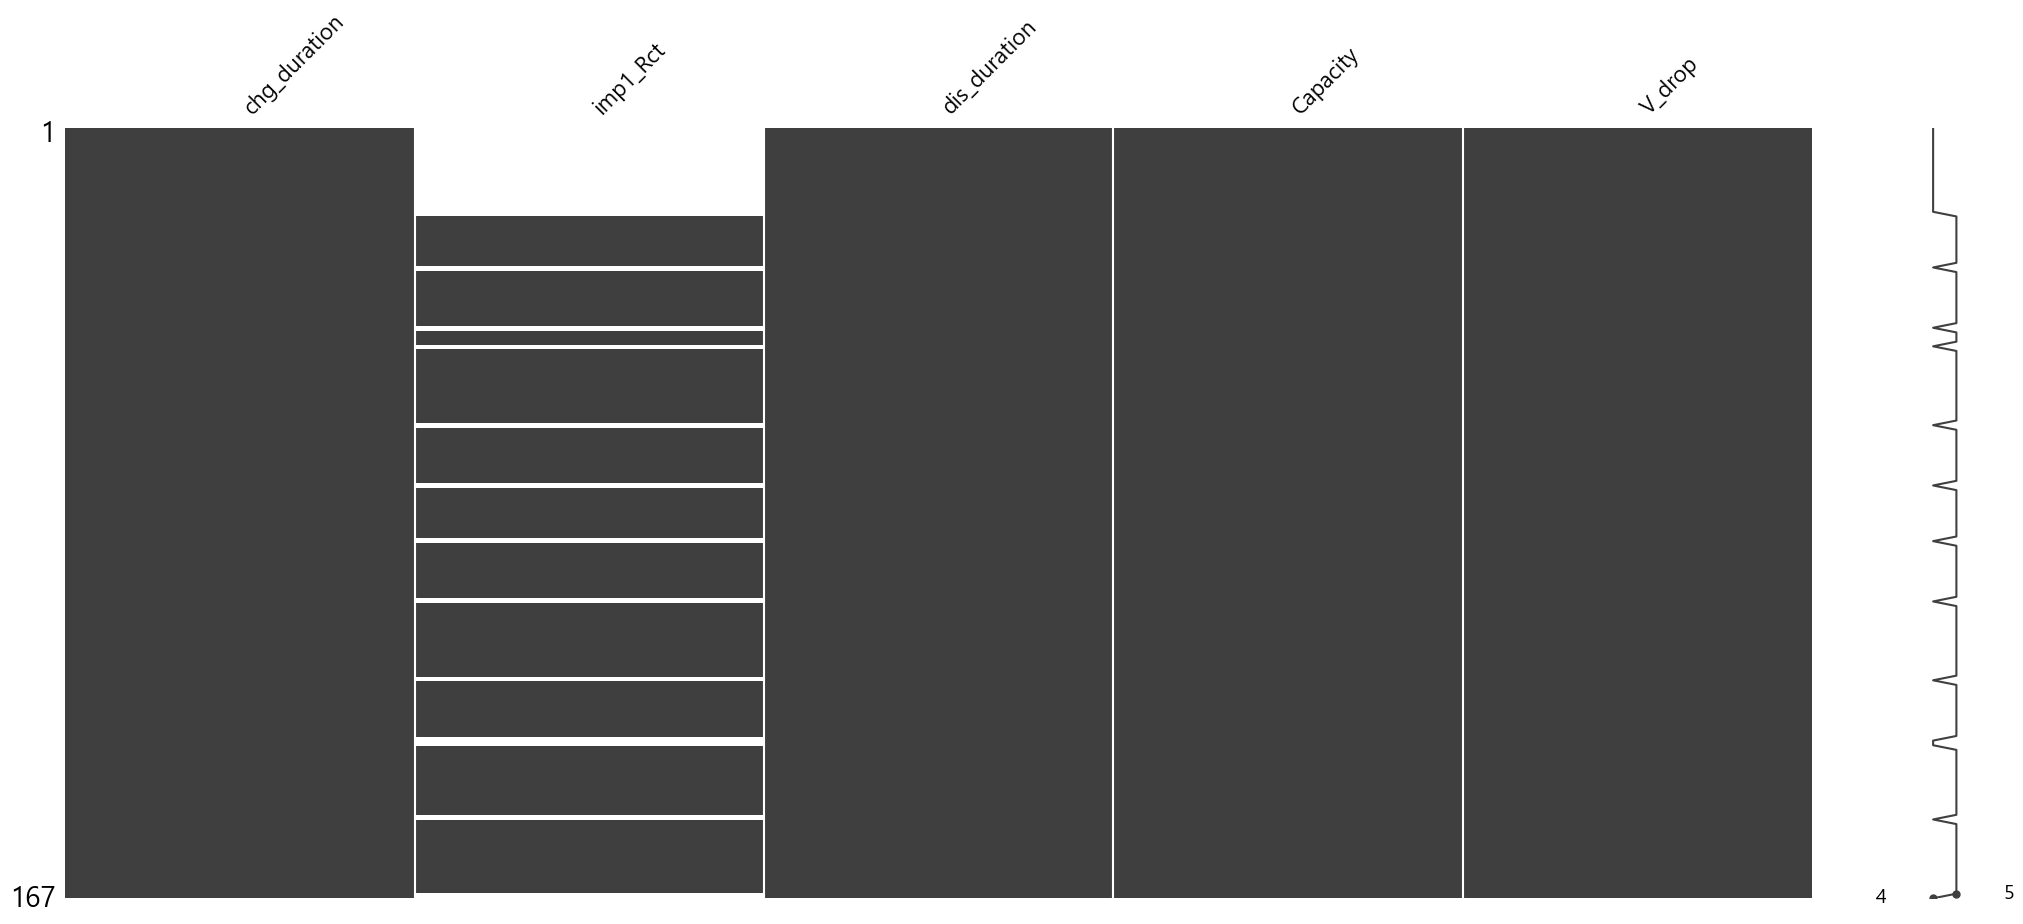

In [21]:
import missingno as msno # missingno 라이브러리가 없다면 pip install missingno

# 주요 변수들의 결측치 패턴 시각화
plt.figure(figsize=(12, 6))
msno.matrix(final_mapped[['chg_duration', 'imp1_Rct', 'dis_duration', 'Capacity', 'V_drop']])
plt.show()

✅ 분석 결과 (데이터 포인트: 136개)
 - Pearson Correlation (선형성): -0.9255
 - Spearman Correlation (순위/경향): -0.9091


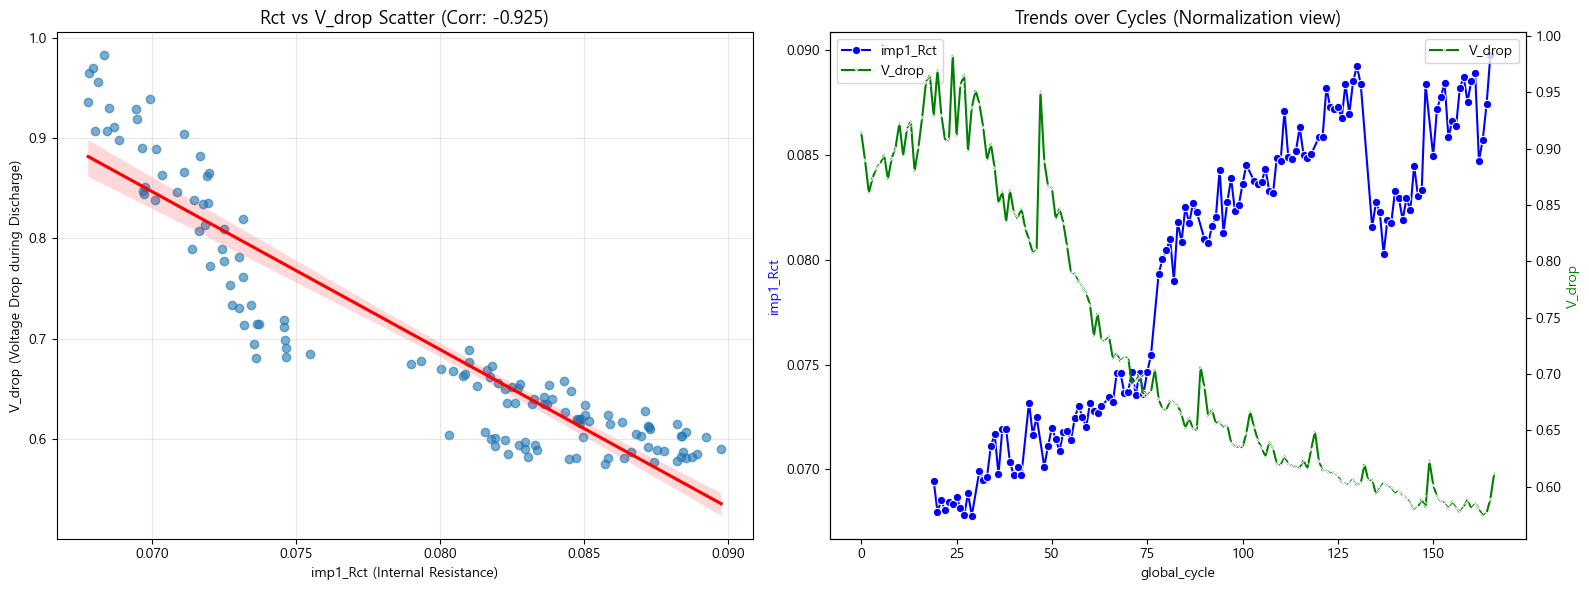

In [22]:
# imp1_Rct vs V_drop 상관관계 분석

def analyze_rct_vdrop_relation(df):
    # 1. 분석에 필요한 데이터만 추출 (결측치 제외)
    temp_df = df[['imp1_Rct', 'V_drop']].dropna()
    
    # 2. 상관계수 계산
    pearson_corr = temp_df.corr(method='pearson').iloc[0, 1]
    spearman_corr = temp_df.corr(method='spearman').iloc[0, 1]
    
    print(f"✅ 분석 결과 (데이터 포인트: {len(temp_df)}개)")
    print(f" - Pearson Correlation (선형성): {pearson_corr:.4f}")
    print(f" - Spearman Correlation (순위/경향): {spearman_corr:.4f}")
    
    # 3. 시각화 (2개 서브플롯)
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # --- 좌측: Scatter Plot + Regression Line ---
    sns.regplot(data=temp_df, x='imp1_Rct', y='V_drop', ax=axes[0], 
                scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
    axes[0].set_title(f'Rct vs V_drop Scatter (Corr: {pearson_corr:.3f})', fontsize=13)
    axes[0].set_xlabel('imp1_Rct (Internal Resistance)')
    axes[0].set_ylabel('V_drop (Voltage Drop during Discharge)')
    axes[0].grid(True, alpha=0.3)
    
    # --- 우측: 시간에 따른 변화 추이 (Dual Axis) ---
    ax2_twin = axes[1].twinx()
    # 전체 df를 사용하여 결측 구간 확인
    sns.lineplot(data=df, x='global_cycle', y='imp1_Rct', ax=axes[1], color='blue', label='imp1_Rct', marker='o')
    sns.lineplot(data=df, x='global_cycle', y='V_drop', ax=ax2_twin, color='green', label='V_drop', marker='x')
    
    axes[1].set_title('Trends over Cycles (Normalization view)', fontsize=13)
    axes[1].set_ylabel('imp1_Rct', color='blue')
    ax2_twin.set_ylabel('V_drop', color='green')
    
    # 범례 합치기
    lines, labels = axes[1].get_legend_handles_labels()
    lines2, labels2 = ax2_twin.get_legend_handles_labels()
    axes[1].legend(lines + lines2, labels + labels2, loc='upper left')
    
    plt.tight_layout()
    plt.show()

# 실행
analyze_rct_vdrop_relation(final_mapped)

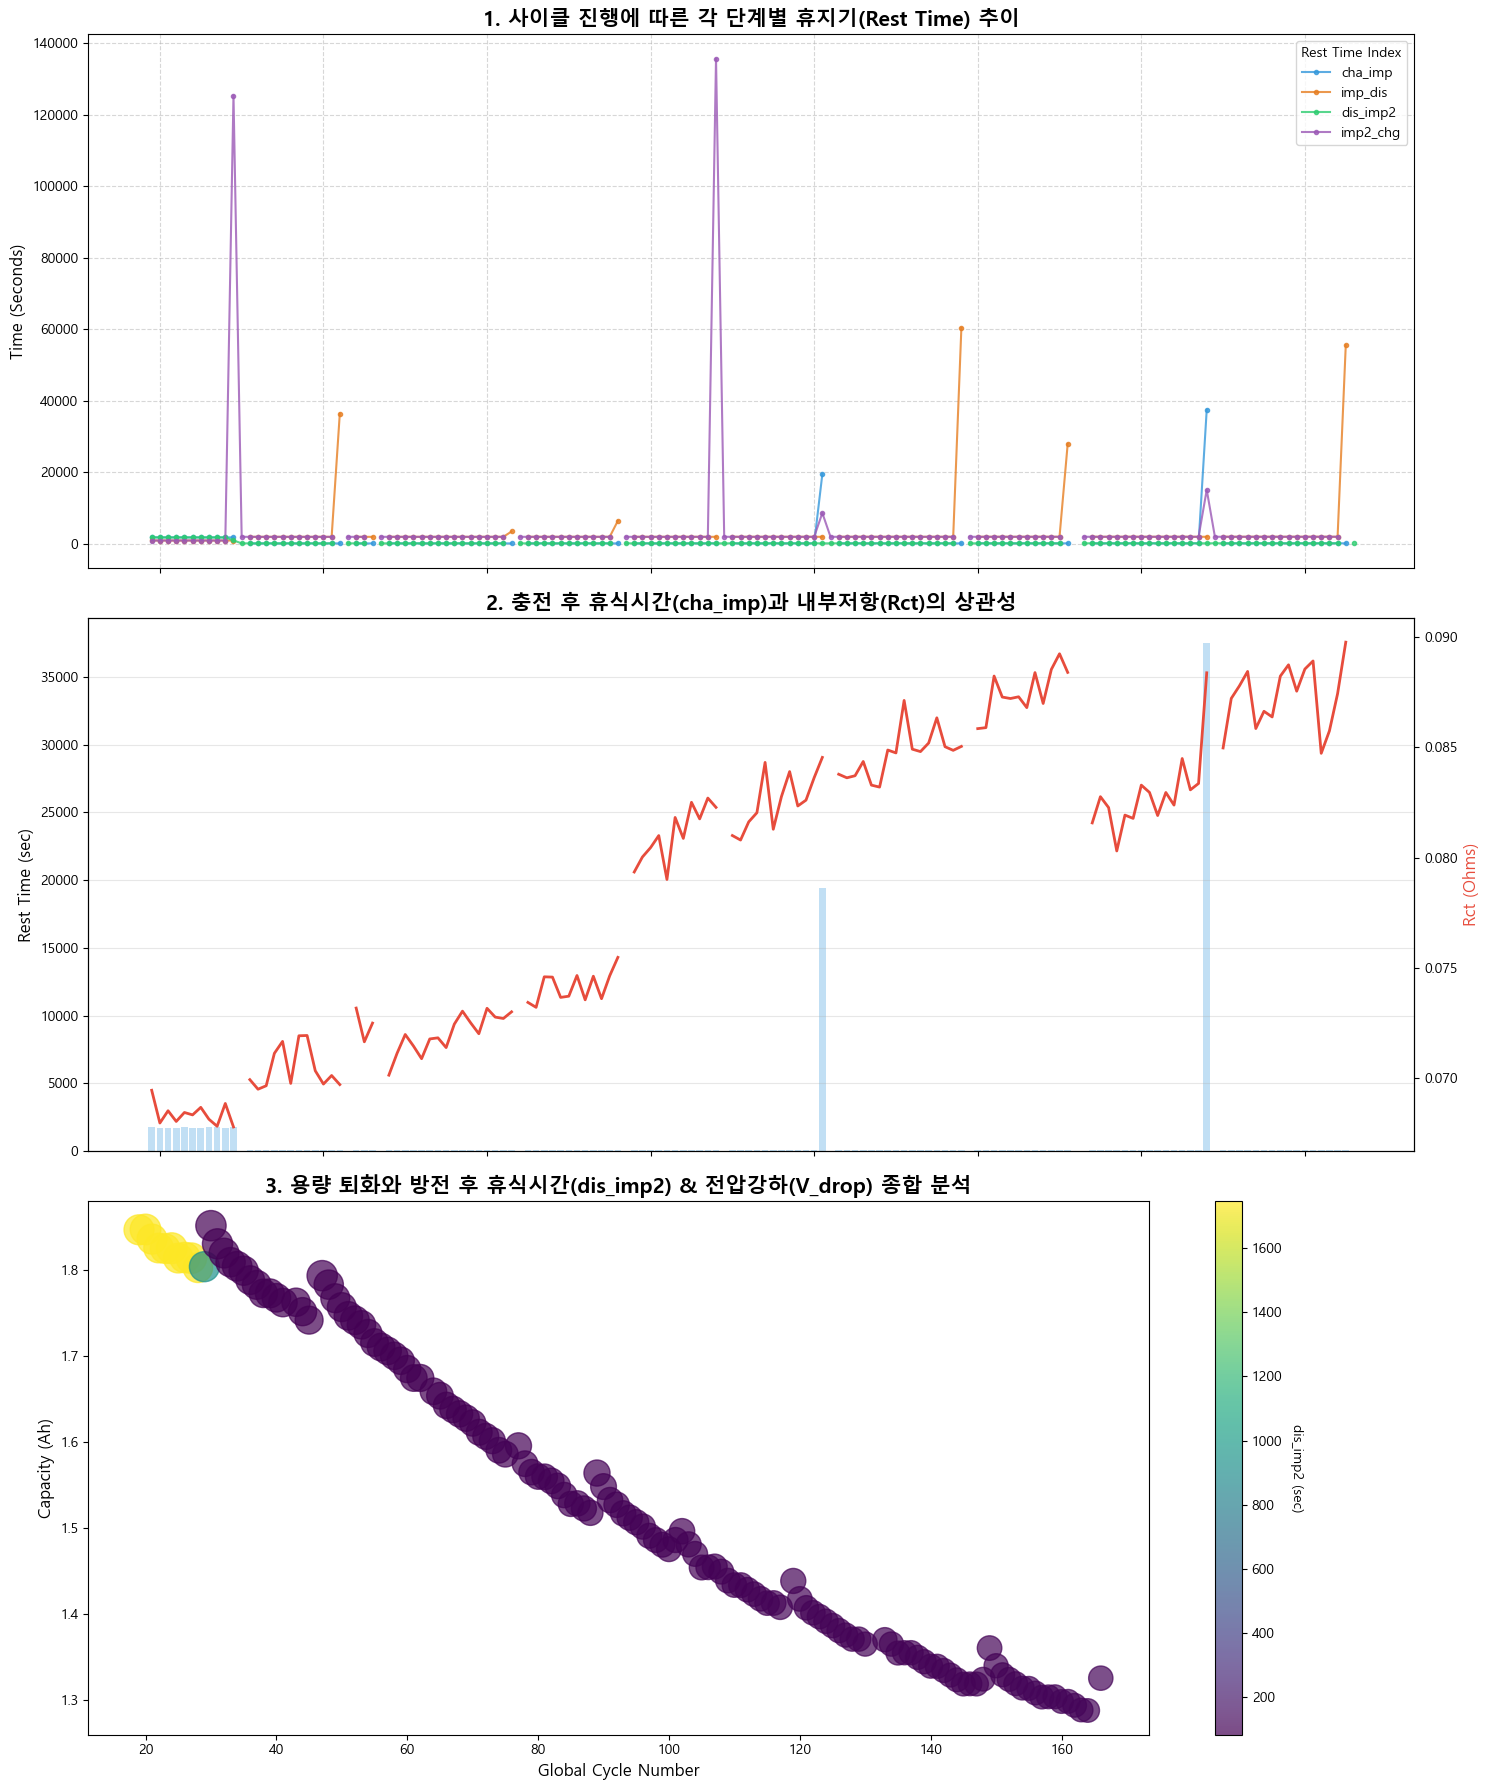

In [ ]:
# 시각화 : 휴지기(Rest Time)와 열화 지표의 상관 분석

def plot_complex_rest_analysis(df):
    # 시각화를 위한 캔버스 설정 (3행 1열)
    fig, axes = plt.subplots(3, 1, figsize=(15, 18), sharex=True)
    
    # 1. 사이클별 휴지기(Rest Time) 변화 추이
    rest_cols = ['cha_imp', 'imp_dis', 'dis_imp2', 'imp2_chg']
    colors = ['#3498db', '#e67e22', '#2ecc71', '#9b59b6']
    
    for col, color in zip(rest_cols, colors):
        axes[0].plot(df['global_cycle'], df[col], label=col, color=color, alpha=0.8, marker='o', markersize=3)
    
    axes[0].set_title('1. 사이클 진행에 따른 각 단계별 휴지기(Rest Time) 추이', fontsize=15, fontweight='bold')
    axes[0].set_ylabel('Time (Seconds)', fontsize=12)
    axes[0].legend(loc='upper right', title='Rest Time Index')
    axes[0].grid(True, linestyle='--', alpha=0.5)

    # 2. 휴지기와 임피던스(Rct)의 관계 (이중축 사용)
    ax2_twin = axes[1].twinx()
    axes[1].bar(df['global_cycle'], df['cha_imp'], color='#3498db', alpha=0.3, label='cha_imp (Rest Before Imp)')
    ax2_twin.plot(df['global_cycle'], df['imp1_Rct'], color='#e74c3c', linewidth=2, label='imp1_Rct (Internal Resistance)')
    
    axes[1].set_title('2. 충전 후 휴식시간(cha_imp)과 내부저항(Rct)의 상관성', fontsize=15, fontweight='bold')
    axes[1].set_ylabel('Rest Time (sec)', fontsize=12)
    ax2_twin.set_ylabel('Rct (Ohms)', fontsize=12, color='#e74c3c')
    axes[1].grid(True, axis='y', alpha=0.3)

    # 3. 방전 후 휴식(dis_imp2)과 용량(Capacity)의 다면 분석 (Scatter)
    scatter = axes[2].scatter(df['global_cycle'], df['Capacity'], 
                              c=df['dis_imp2'], cmap='viridis', s=df['V_drop']*500, alpha=0.7)
    
    axes[2].set_title('3. 용량 퇴화와 방전 후 휴식시간(dis_imp2) & 전압강하(V_drop) 종합 분석', fontsize=15, fontweight='bold')
    axes[2].set_ylabel('Capacity (Ah)', fontsize=12)
    axes[2].set_xlabel('Global Cycle Number', fontsize=12)
    
    # 컬러바 및 범례 추가
    cbar = plt.colorbar(scatter, ax=axes[2])
    cbar.set_label('dis_imp2 (sec)', rotation=270, labelpad=15)
    
    # 전체 레이아웃 조정
    plt.tight_layout()
    plt.show()

# 시각화 실행
plot_complex_rest_analysis(final_mapped)

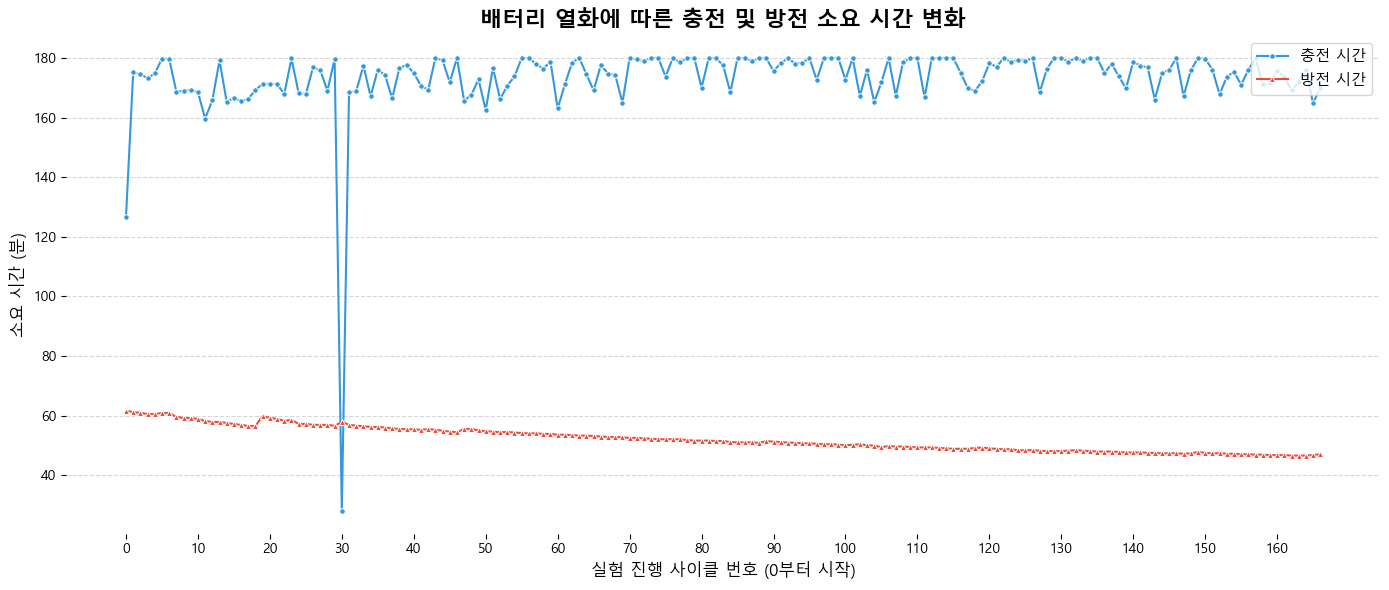

In [17]:
def plot_cycle_durations(df):
    """
    사이클 진행에 따른 충전 및 방전 소요 시간 변화 시각화
    """
    # X축으로 사용할 가상의 사이클 번호 생성 (0부터 시작)
    df = df.reset_index().rename(columns={'index': 'cycle_number'})
    
    # 초(second) 단위를 분(minute) 단위로 변환하여 시각화 (가독성 향상)
    df['chg_dur_min'] = df['chg_duration'] / 60
    df['dis_dur_min'] = df['dis_duration'] / 60
    
    plt.figure(figsize=(14, 6))
    
    # Seaborn을 이용한 스택형 라인 그래프(실제로는 개별 라인)
    sns.lineplot(data=df, x='global_cycle', y='chg_dur_min', label='충전 시간', color='#3498db', marker='o', markersize=4)
    sns.lineplot(data=df, x='global_cycle', y='dis_dur_min', label='방전 시간', color='#e74c3c', marker='^', markersize=4)
    
    # 그래프 꾸미기
    plt.title('배터리 열화에 따른 충전 및 방전 소요 시간 변화', fontsize=16, fontweight='bold')
    plt.xlabel('실험 진행 사이클 번호 (0부터 시작)', fontsize=12)
    plt.ylabel('소요 시간 (분)', fontsize=12)
    plt.legend(fontsize=11, loc='upper right')
    plt.xticks(np.arange(0, len(df)+1, 10)) # X축 눈금 조절 (10단위)
    
    # 그리드 추가 (옅게)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    
    # 불필요한 테두리 제거 (Seaborn style과 조합)
    sns.despine(left=True, bottom=True)
    
    plt.tight_layout()
    plt.show()

# 그래프 실행
plot_cycle_durations(final_mapped)

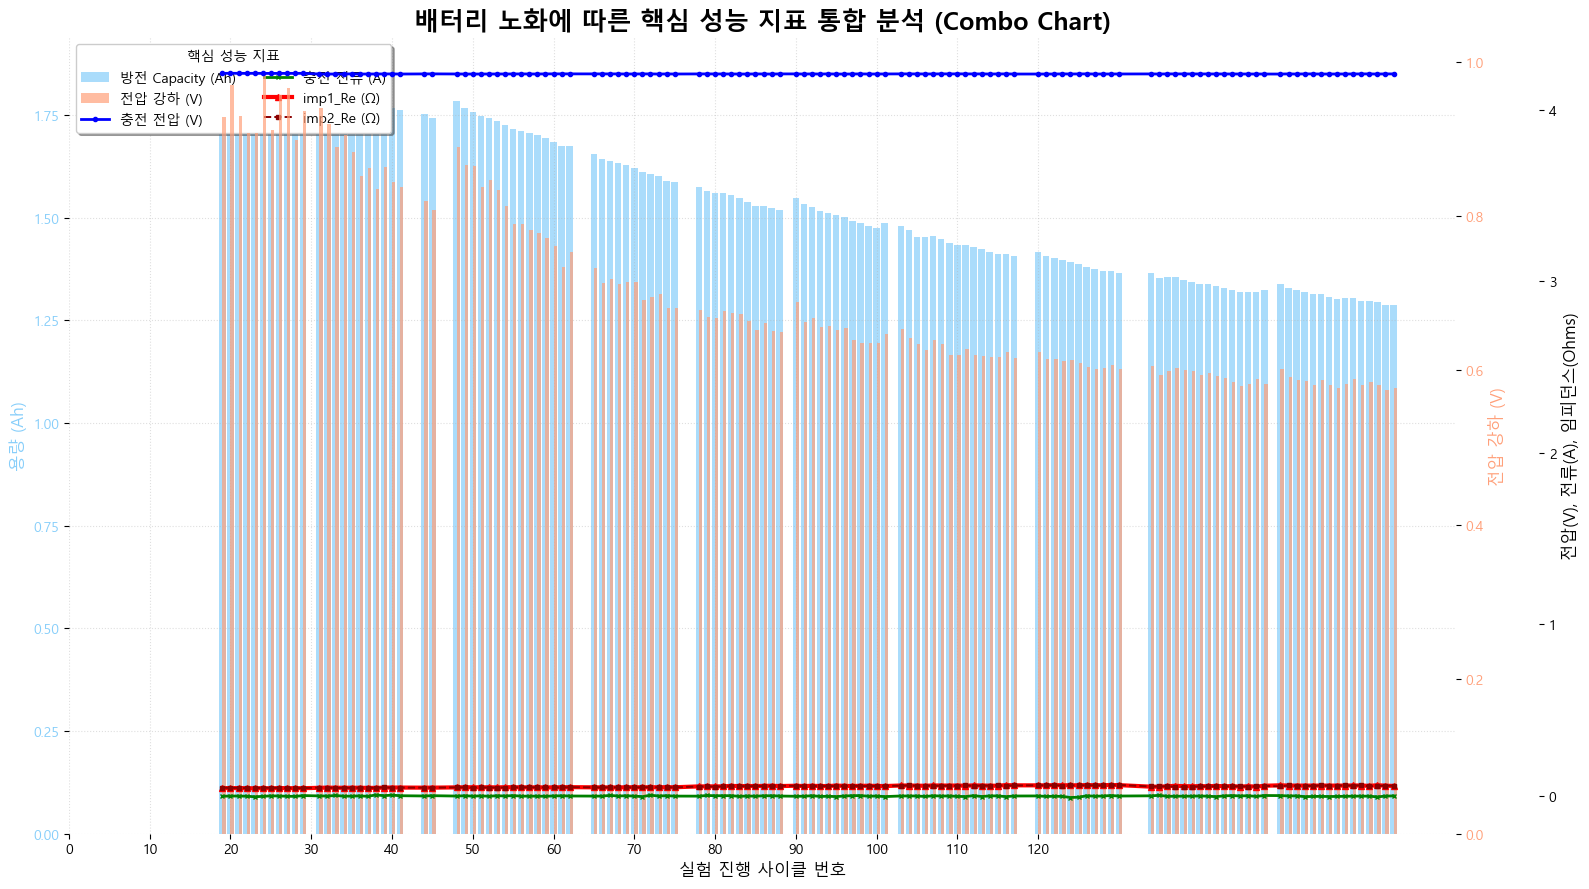

In [19]:
def plot_integrated_battery_combo_chart(df):
    """
    이중 축과 Combo 그래프를 활용한 배터리 핵심 지표 통합 시각화 (다면 분석)
    (막대: Capacity, 전압 강하 / 라인: 전압, 전류, 임피던스)
    """
    # X축용 사이클 번호 생성
    df_plot = df.reset_index().rename(columns={'index': 'cycle_number'})
    
    # NaN 값 제거 (그래프 끊김 방지) - 용량, 임피던스, 전압 강하가 모두 있는 행만 사용
    df_plot = df_plot.dropna(subset=['Capacity', 'imp1_Re', 'imp2_Re', 'V_drop'])
    
    fig, ax1 = plt.subplots(figsize=(16, 9))
    
    # --- 왼쪽 Y축 (ax1): 용량(Capacity) 및 전압 강하(V_drop) ---
    # 그래프 종류: 막대 (Bar) - 값이 명확히 끊어지는 지표에 적합
    # 색상 조합: 파스텔 톤 (막대가 라인을 가리지 않게)
    color_cap = '#87CEFA' # 연한 파랑
    color_vdrop = '#FFA07A' # 연한 주황
    
    ax1.bar(df_plot['cycle_number'], df_plot['Capacity'], label='방전 Capacity (Ah)', color=color_cap, alpha=0.7)
    
    # V_drop은 다른 축을 사용하여 표현 (막대 그래프 겹침 방지 및 가독성 향상)
    ax_vdrop = ax1.twinx()
    ax_vdrop.bar(df_plot['cycle_number'], df_plot['V_drop'], label='전압 강하 (V)', color=color_vdrop, alpha=0.7, width=0.4, align='edge')
    ax_vdrop.set_ylabel('전압 강하 (V)', fontsize=12, color=color_vdrop)
    ax_vdrop.tick_params(axis='y', labelcolor=color_vdrop)

    ax1.set_xlabel('실험 진행 사이클 번호', fontsize=12)
    ax1.set_ylabel('용량 (Ah)', fontsize=12, color=color_cap)
    ax1.tick_params(axis='y', labelcolor=color_cap)
    
    # --- 오른쪽 Y축 (ax2): 전압, 전류, 임피던스 (Re) ---
    # 그래프 종류: 라인 (Line) - 추세 변화를 봐야 하는 지표에 적합
    # 색상 조합: 원색 톤 (추세가 뚜렷하게 보이게)
    ax2 = ax1.twinx() # 세 번째 Y축 생성 (기본 ax2가 있지만, vdrop용으로 twinx를 한 번 더 사용해서 ax2로 정의)
    ax2.spines['right'].set_position(('outward', 60)) # 세 번째 축 위치 조절 (가독성 향상)
    
    line_width = 2
    ax2.plot(df_plot['cycle_number'], df_plot['Voltage_charge'], label='충전 전압 (V)', color='blue', linewidth=line_width, marker='o', markersize=3)
    ax2.plot(df_plot['cycle_number'], df_plot['Current_charge'], label='충전 전류 (A)', color='green', linewidth=line_width, marker='x', markersize=3)
    
    # 임피던스는 더 굵게 (핵심 지표)
    ax2.plot(df_plot['cycle_number'], df_plot['imp1_Re'], label='imp1_Re (Ω)', color='red', linewidth=line_width*1.5, marker='^', markersize=4)
    ax2.plot(df_plot['cycle_number'], df_plot['imp2_Re'], label='imp2_Re (Ω)', color='darkred', linewidth=line_width*0.7, linestyle='--', marker='s', markersize=3)

    ax2.set_ylabel('전압(V), 전류(A), 임피던스(Ohms)', fontsize=12)
    
    # --- 전체 그래프 꾸미기 ---
    plt.title('배터리 노화에 따른 핵심 성능 지표 통합 분석 (Combo Chart)', fontsize=18, fontweight='bold')
    
    # 범례 설정 (ax1, ax_vdrop, ax2의 범례를 합쳐서 하나로 만듦)
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines_vd, labels_vd = ax_vdrop.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    
    # 범례 합치기 및 가독성 향상 (예: imp1_Re -> 초기 임피던스)
    all_lines = lines1 + lines_vd + lines2
    all_labels = labels1 + labels_vd + labels2
    
    ax1.legend(all_lines, all_labels, loc='upper left', ncol=2, fontsize=10, 
               frameon=True, shadow=True, title='핵심 성능 지표')
    
    # X축 눈금 조절
    ax1.set_xticks(np.arange(0, len(df_plot)+1, 10))
    
    # 옅은 그리드 추가 (전체적으로)
    ax1.grid(axis='both', linestyle=':', alpha=0.4)
    
    # 불필요한 테두리 제거
    sns.despine(left=True, bottom=True, right=True)
    
    plt.tight_layout()
    plt.show()

# 그래프 실행
plot_integrated_battery_combo_chart(final_mapped)

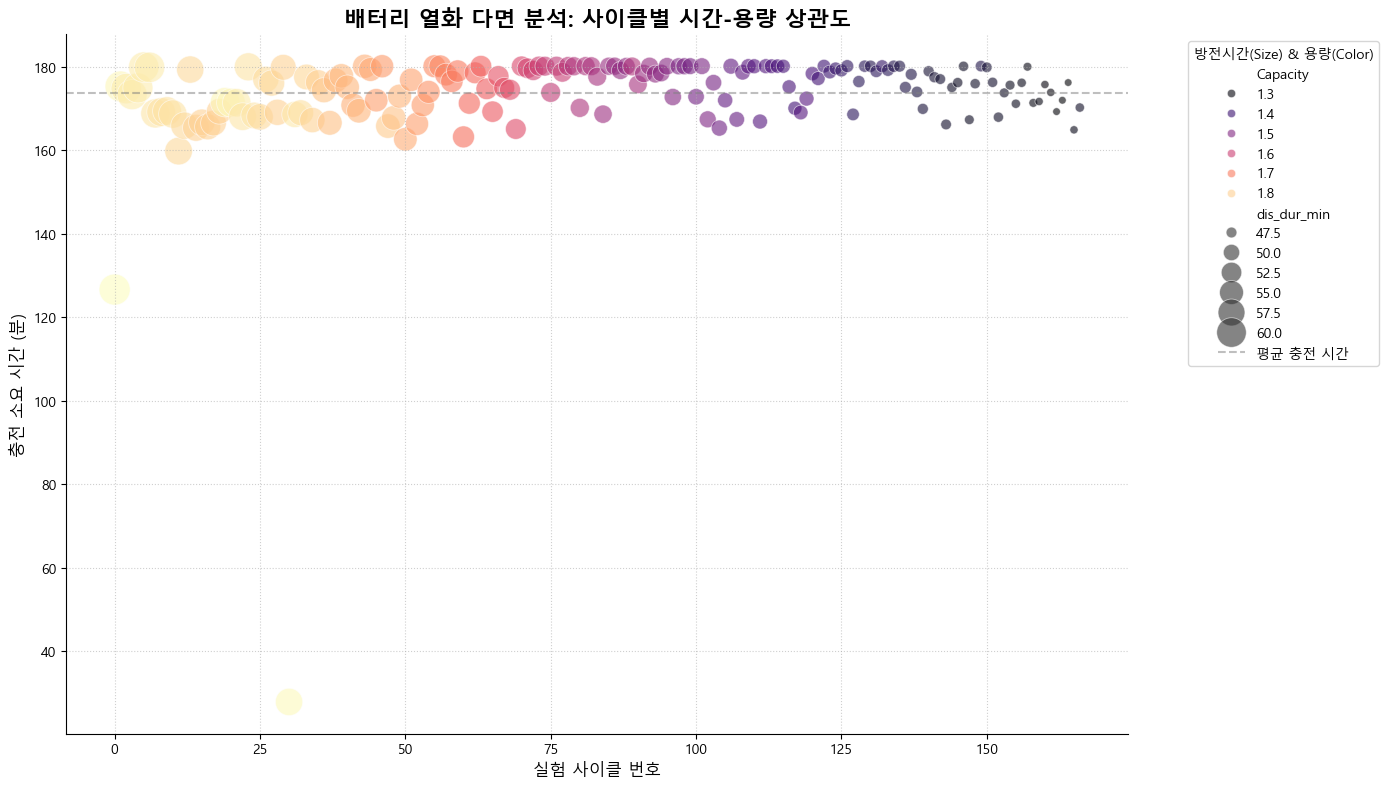

In [26]:
def plot_timeline_efficiency(df):
    """
    사이클 진행에 따른 충/방전 시간 변화 및 용량과의 상관관계 시각화
    """
    # 1. 내부 변수명 통일 (NameError 해결 지점)
    df_plot = df.reset_index().rename(columns={'index': 'cycle_number'})
    
    # 초 -> 분 변환 및 결측치 제거
    df_plot['chg_dur_min'] = df_plot['chg_duration'] / 60
    df_plot['dis_dur_min'] = df_plot['dis_duration'] / 60
    df_plot = df_plot.dropna(subset=['chg_dur_min', 'dis_dur_min', 'Capacity'])
    
    plt.figure(figsize=(14, 8))
    
    # 2. scatterplot의 data 인자를 df_plot으로 수정
    scatter = sns.scatterplot(data=df_plot, x='global_cycle', y='chg_dur_min', 
                              size='dis_dur_min', hue='Capacity', 
                              sizes=(30, 500), palette='magma', alpha=0.6)
    
    # 미래지향적 분석: 배터리 수명 종료(EOL) 가이드라인 추가 (초기 용량의 80% 가정)
    initial_cap = df_plot['Capacity'].iloc[0]
    eol_threshold = initial_cap * 0.8
    plt.axhline(y=df_plot['chg_dur_min'].mean(), color='gray', linestyle='--', alpha=0.5, label='평균 충전 시간')
    
    plt.title('배터리 열화 다면 분석: 사이클별 시간-용량 상관도', fontsize=16, fontweight='bold')
    plt.xlabel('실험 사이클 번호', fontsize=12)
    plt.ylabel('충전 소요 시간 (분)', fontsize=12)
    
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='방전시간(Size) & 용량(Color)')
    plt.grid(True, linestyle=':', alpha=0.6)
    sns.despine()
    plt.tight_layout()
    plt.show()

# 실행
plot_timeline_efficiency(final_mapped)

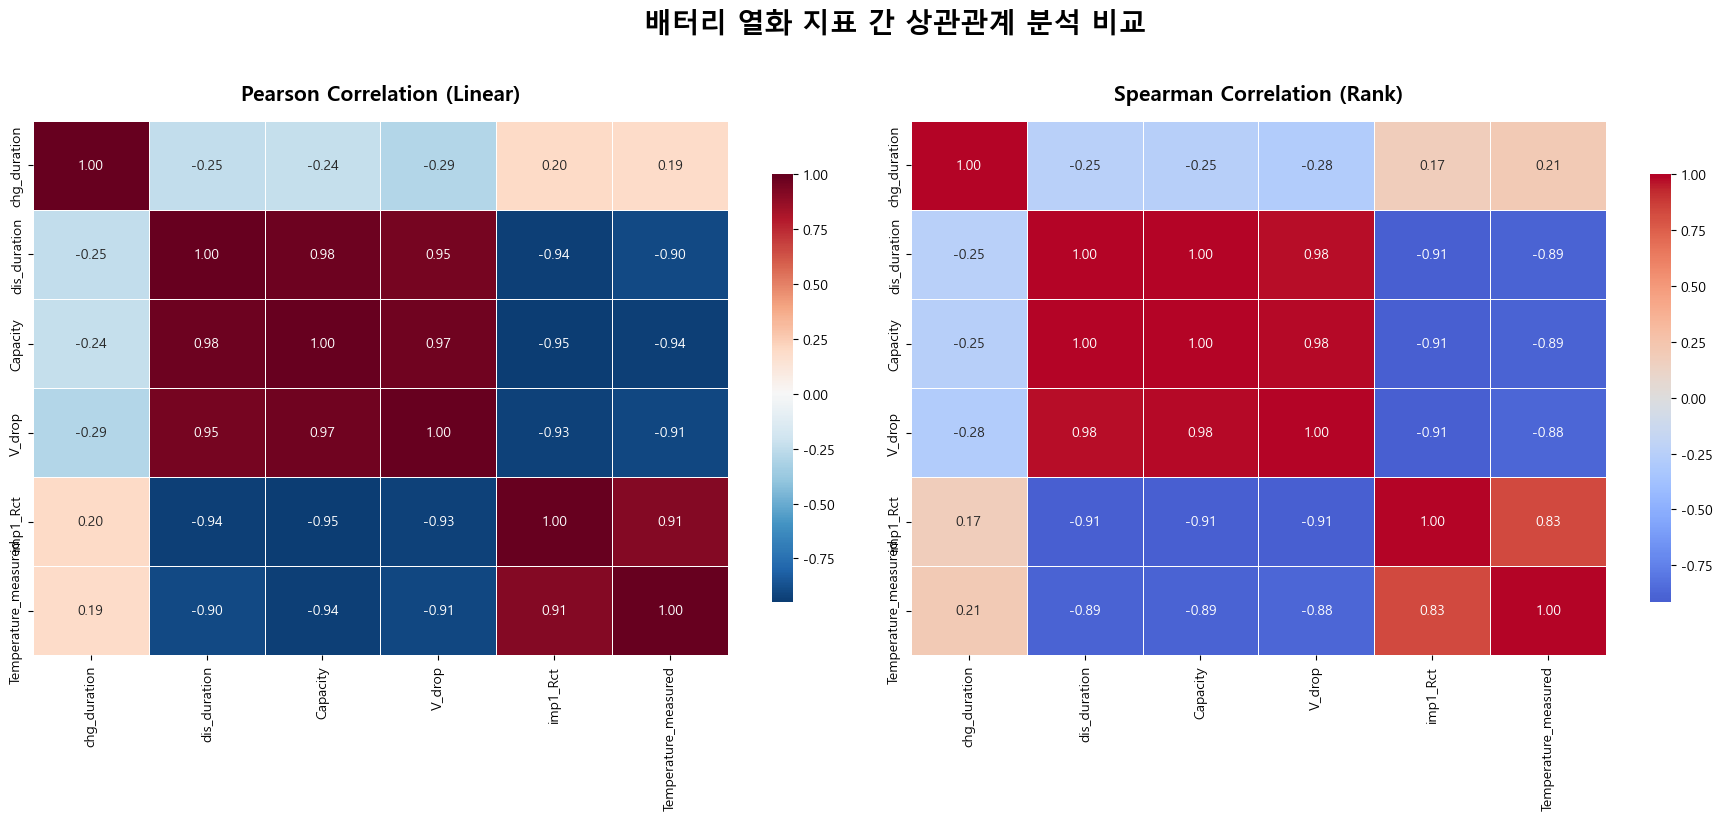

In [27]:
# Pearson 상관계수 : 두 지표가 얼마나 '직선(Linear)'으로 같이 움직이는가?를 측정 (이상치에 수치 크게 왜곡)
# Spearman 상관계수 : 두 지표의 '순위(Rank)'가 일치하는가?를 측정 (순서 중시, 이상치에 강함 피어슨보다 나음)

def plot_correlation_comparison(df):
    """
    Pearson(선형)과 Spearman(순위) 상관계수를 한눈에 비교하여 
    지표 간의 관계 특성을 분석합니다.
    """
    # 1. 분석 대상 컬럼 선정 및 데이터 타입 변환
    cols = ['chg_duration', 'dis_duration', 'Capacity', 'V_drop', 'imp1_Rct', 'Temperature_measured']
    valid_cols = [c for c in cols if c in df.columns]
    
    # 2. 상관계수 계산
    corr_pearson = df[valid_cols].astype(float).corr(method='pearson')
    corr_spearman = df[valid_cols].corr(method='spearman')
    
    # 3. 그래프 영역 생성 (1행 2열)
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    
    # --- 좌측: Pearson Heatmap ---
    sns.heatmap(corr_pearson, annot=True, cmap='RdBu_r', center=0, fmt='.2f', 
                linewidths=0.5, ax=axes[0], cbar_kws={'shrink': 0.8})
    axes[0].set_title('Pearson Correlation (Linear)', fontsize=15, pad=15, fontweight='bold')
    
    # --- 우측: Spearman Heatmap ---
    # 시각적 구분을 위해 다른 팔레트(viridis 등)를 사용할 수도 있습니다.
    sns.heatmap(corr_spearman, annot=True, cmap='coolwarm', center=0, fmt='.2f', 
                linewidths=0.5, ax=axes[1], cbar_kws={'shrink': 0.8})
    axes[1].set_title('Spearman Correlation (Rank)', fontsize=15, pad=15, fontweight='bold')
    
    # 레이아웃 정리
    plt.suptitle('배터리 열화 지표 간 상관관계 분석 비교', fontsize=20, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

# 실행
plot_correlation_comparison(final_mapped)

# 두 계수의 비교 분석 (plot_corr_compare) 데이터의 관계가 선형인가, 비선형인가?를 판별
# 피어슨은 직선을 찾고, 스피어먼은 순서를 찾습니다. 만약 두 그래프의 수치가 거의 비슷하다면 여러분의 배터리 데이터는 아주 정직하게(선형적으로) 노화되고 있다는 뜻
# 해석 시 참고
# 둘 다 높음	두 지표는 아주 깨끗한 직선 관계임. (예: Capacity vs dis_duration)
# Spearman > Pearson	관계는 확실히 있는데 곡선 형태임. (열화가 가속화되고 있음)
# 둘 다 낮음	두 지표는 서로 아무 상관이 없음. (모델링에서 제외할 변수)


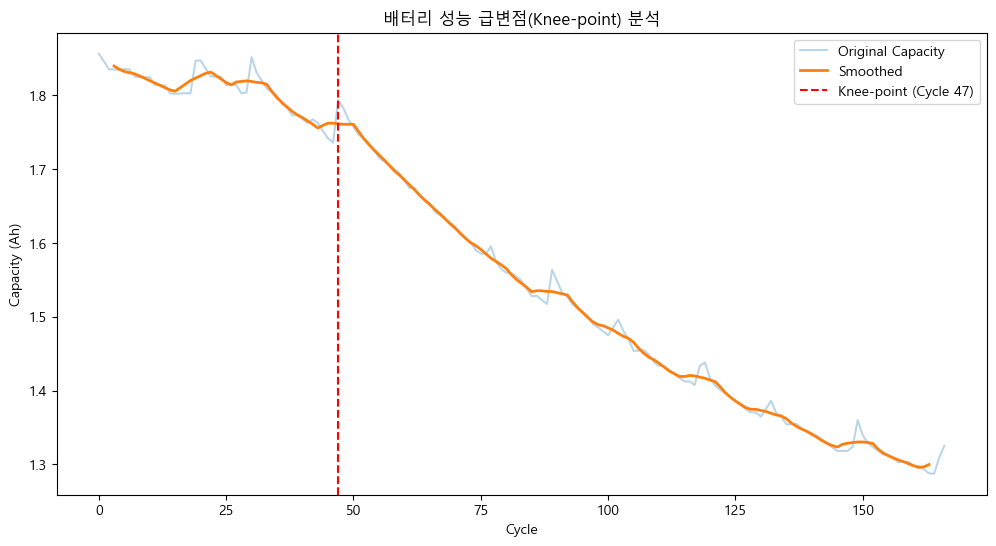

In [28]:
# Knee-point(급격한 성능 저하 지점) 검출

def find_knee_point(df):
    """
    Capacity가 급격히 감소하기 시작하는 지점을 검출합니다.
    """
    # 7점 이동 평균으로 노이즈 제거
    df['Capacity_smooth'] = df['Capacity'].rolling(window=7, center=True).mean()
    
    # 2차 미분 기반 knee-point 검출
    valid_cap = df['Capacity_smooth'].dropna()

    grad2 = np.gradient(np.gradient(valid_cap))
    knee_point_idx = np.argmax(np.abs(grad2))
    
    plt.figure(figsize=(12, 6))
    plt.plot(df.index, df['Capacity'], label='Original Capacity', alpha=0.3)
    plt.plot(df.index, df['Capacity_smooth'], label='Smoothed', linewidth=2)
    
    # 임계점 표시
    plt.axvline(x=knee_point_idx, color='red', linestyle='--', label=f'Knee-point (Cycle {knee_point_idx})')
    
    plt.title('배터리 성능 급변점(Knee-point) 분석')
    plt.xlabel('Cycle')
    plt.ylabel('Capacity (Ah)')
    plt.legend()
    plt.show()

find_knee_point(final_mapped)

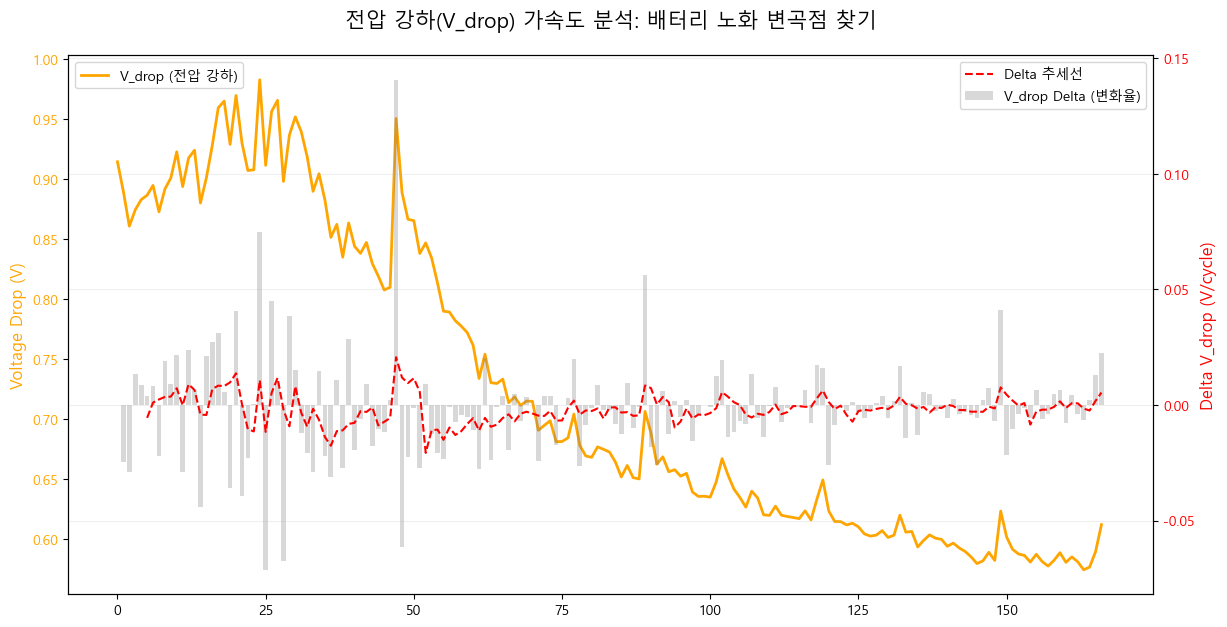

In [29]:
# V_drop 델타(변화율) 시각화: 성능 절벽 포착하기


def plot_vdrop_delta_analysis(df):
    df_plot = df.copy().reset_index().rename(columns={'index': 'cycle'})
    
    # V_drop의 변화량(Delta) 계산
    df_plot['V_drop_delta'] = df_plot['V_drop'].diff()
    
    # 노이즈 제거를 위한 이동 평균
    df_plot['V_drop_delta_smooth'] = df_plot['V_drop_delta'].rolling(window=5).mean()

    fig, ax1 = plt.subplots(figsize=(14, 7))

    # 1. V_drop 추세 (Line)
    ax1.plot(df_plot['cycle'], df_plot['V_drop'], color='orange', label='V_drop (전압 강하)', linewidth=2)
    ax1.set_ylabel('Voltage Drop (V)', color='orange', fontsize=12)
    ax1.tick_params(axis='y', labelcolor='orange')

    # 2. V_drop 변화율 (Bar) - 갑자기 튀는 구간 확인용
    ax2 = ax1.twinx()
    ax2.bar(df_plot['cycle'], df_plot['V_drop_delta'], color='gray', alpha=0.3, label='V_drop Delta (변화율)')
    ax2.plot(df_plot['cycle'], df_plot['V_drop_delta_smooth'], color='red', linestyle='--', label='Delta 추세선')
    ax2.set_ylabel('Delta V_drop (V/cycle)', color='red', fontsize=12)
    ax2.tick_params(axis='y', labelcolor='red')

    plt.title('전압 강하(V_drop) 가속도 분석: 배터리 노화 변곡점 찾기', fontsize=15, pad=20)
    ax1.legend(loc='upper left')
    ax2.legend(loc='upper right')
    plt.grid(True, alpha=0.2)
    plt.show()

plot_vdrop_delta_analysis(final_mapped)

모델 설명력(R2 Score): 0.9844


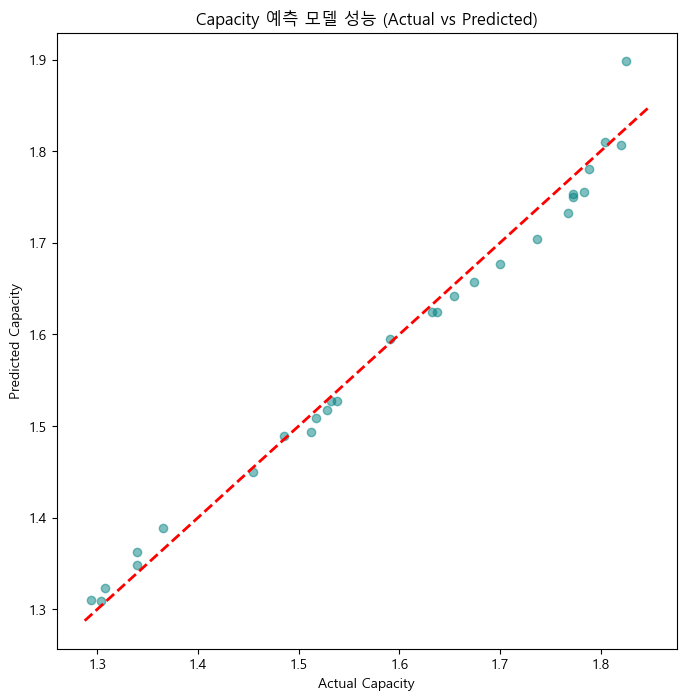

In [30]:
# [미래 예측 모델] 선형 회귀를 이용한 잔여 수명(RUL) 예측

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

def predict_battery_soh(df):
    # 히트맵에서 상관관계가 높았던 지표들 선택
    features = ['dis_duration', 'V_drop', 'imp1_Rct']
    
    # 결측치 제거
    data = df.dropna(subset=features + ['Capacity'])
    
    X = data[features]
    y = data['Capacity']
    
    # 데이터 분할 (학습 8 : 테스트 2)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    print(f"모델 설명력(R2 Score): {r2_score(y_test, y_pred):.4f}")
    
    # 실제값 vs 예측값 시각화
    plt.figure(figsize=(8, 8))
    plt.scatter(y_test, y_pred, alpha=0.5, color='teal')
    plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
    plt.title('Capacity 예측 모델 성능 (Actual vs Predicted)')
    plt.xlabel('Actual Capacity')
    plt.ylabel('Predicted Capacity')
    plt.show()

predict_battery_soh(final_mapped)

# 검증된물리적특성에 배터리열화는 초반완만 중반 안정 후반 급격감소의 비선형이므로
# 선형 모델은 단순 근사이며 실제 열화 특성은 비선형이다

In [31]:
# 미래 예측: 배터리 교체 시점(RUL) 계산 코드

from sklearn.linear_model import LinearRegression

def estimate_replacement_cycle(df, threshold_percent=0.8):
    # 1. 기준점 설정 (초기 용량의 80%)
    initial_cap = df['Capacity'].dropna().iloc[0]
    eol_threshold = initial_cap * threshold_percent
    
    # 2. 선형 회귀 모델 준비 (Cycle 수 -> Capacity 예측)
    df_model = df.dropna(subset=['Capacity']).reset_index()
    X = df_model[['index']] # 사이클 번호
    y = df_model['Capacity']
    
    model = LinearRegression()
    model.fit(X, y)
    
    # 3. 기울기(Slope)와 절편(Intercept) 추출: y = ax + b
    slope = model.coef_[0]
    intercept = model.intercept_
    
    # 4. 목표 용량(eol_threshold)에 도달하는 x(Cycle) 계산
    # eol_threshold = slope * target_cycle + intercept
    target_cycle = (eol_threshold - intercept) / slope
    
    remaining_cycles = target_cycle - df_model['index'].max()
    
    print(f"--- 배터리 수명 예측 결과 ---")
    print(f"초기 용량: {initial_cap:.4f} Ah")
    print(f"교체 기준(80%): {eol_threshold:.4f} Ah")
    print(f"예상 교체 사이클: 제 {int(target_cycle)}회차")
    print(f"현재 기준 남은 수명: 약 {int(remaining_cycles)} 사이클")
    
    return target_cycle, eol_threshold

# 실행
target_cycle, eol_val = estimate_replacement_cycle(final_mapped)

# 부정확

--- 배터리 수명 예측 결과 ---
초기 용량: 1.8565 Ah
교체 기준(80%): 1.4852 Ah
예상 교체 사이클: 제 105회차
현재 기준 남은 수명: 약 -60 사이클


a

a


a

a

a

a

a

a

a

a

a

a


In [ ]:
final_mapped.info() # 형변환이전에 찍어봄

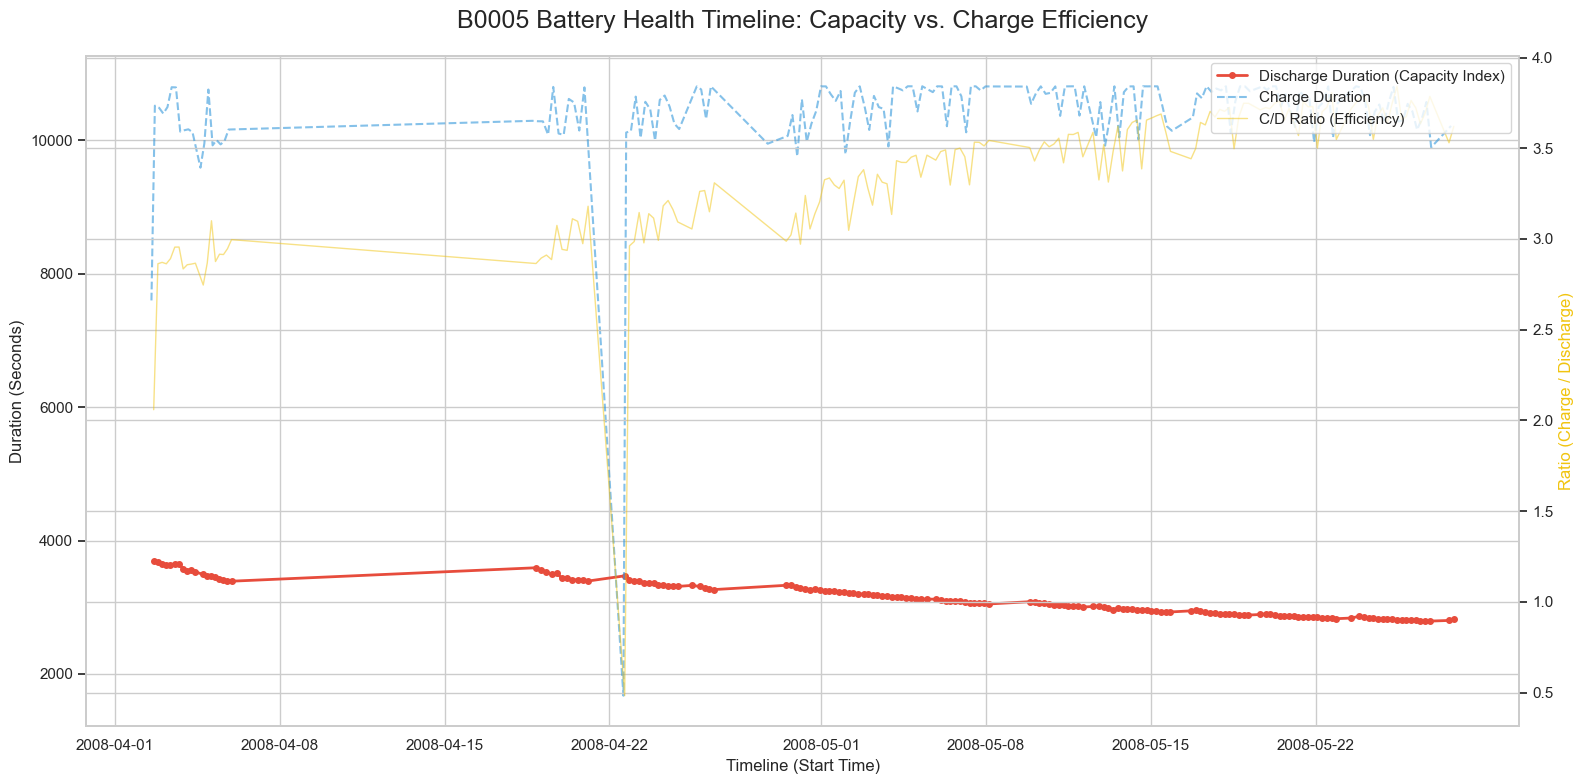

In [32]:
# 1. 충전 vs 방전 지속 시간 (Efficiency & SOH)
# 2. 방전 시간 대비 충전 시간의 비율 (C/D Ratio)
# chg_duration / dis_duration 비율을 계산 : 배터리가 건강할 때는 이 비율이 일정하다가, 수명 종료(EOL) 시점에 가까워질수록 이 균형이 깨짐
# 비율이 급격히 변하는 지점이 바로 배터리의 성질이 변하는 'Critical Point'

# 1. 스타일 설정
sns.set_theme(style="whitegrid")
fig, ax1 = plt.subplots(figsize=(16, 8))

# 2. 첫 번째 축: 방전 및 충전 시간 (절대적인 성능 지표)
ax1.plot(final_mapped['dis_start'], final_mapped['dis_duration'], 
         label='Discharge Duration (Capacity Index)', color='#e74c3c', marker='o', markersize=4, linewidth=2)
ax1.plot(final_mapped['chg_start'], final_mapped['chg_duration'], 
         label='Charge Duration', color='#3498db', alpha=0.6, linestyle='--')

ax1.set_xlabel('Timeline (Start Time)', fontsize=12)
ax1.set_ylabel('Duration (Seconds)', fontsize=12)
ax1.tick_params(axis='y')

# 3. 두 번째 축 (TwinX): 충전/방전 비율 (Efficiency Index)
# 배터리가 노후화될수록 적게 담기고(방전 짧아짐) 충전 양상은 변하므로 이 비율이 중요합니다.
ax2 = ax1.twinx()
cd_ratio = final_mapped['chg_duration'] / final_mapped['dis_duration']
ax2.plot(final_mapped['dis_start'], cd_ratio, 
         label='C/D Ratio (Efficiency)', color='#f1c40f', linewidth=1, alpha=0.5)
ax2.set_ylabel('Ratio (Charge / Discharge)', fontsize=12, color='#f1c40f')

# 4. 마무리
plt.title('B0005 Battery Health Timeline: Capacity vs. Charge Efficiency', fontsize=18, pad=20)
fig.legend(loc="upper right", bbox_to_anchor=(1, 1), bbox_transform=ax1.transAxes)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# 절대 시간 흐름에 따른 '점진적 열화' 확인


In [34]:
final_mapped.columns

Index(['chg_t_cycle', 'chg_start', 'chg_duration', 'cha_imp', 'Voltage_charge',
       'Current_charge', 'imp_t_cycle', 'imp_start', 'imp1_Re', 'imp1_Rct',
       'imp_dis', 'dis_t_cycle', 'dis_start', 'dis_duration', 'Capacity',
       'V_drop', 'Voltage_measured', 'Temperature_measured', 'dis_imp2',
       'imp2_t_cycle', 'imp2_start', 'imp2_Re', 'imp2_Rct', 'imp2_chg',
       'global_cycle', 'Capacity_smooth'],
      dtype='object')

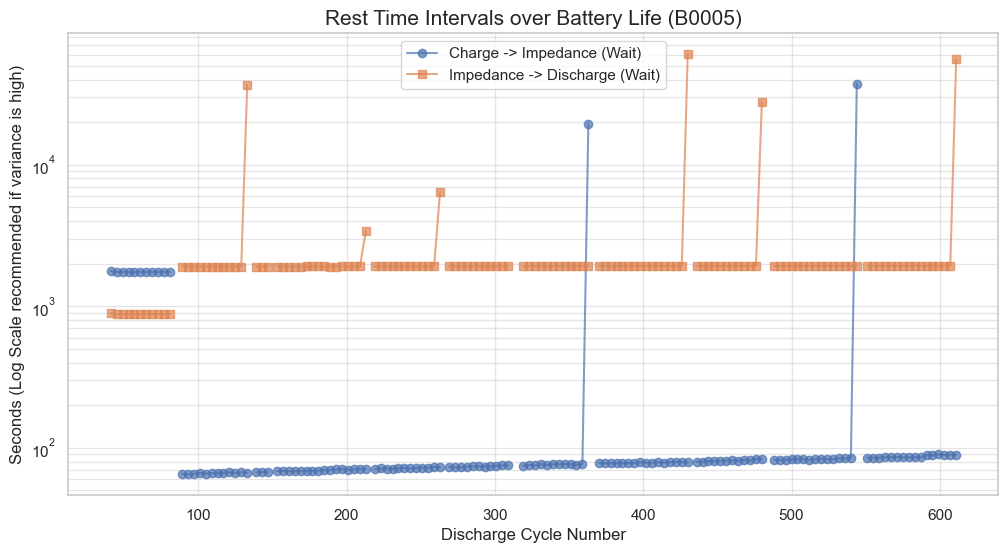

In [35]:
# 시각화 : 배터리 수명 흐름도

plt.figure(figsize=(12, 6))

# X축을 방전 사이클 번호로 설정
plt.plot(final_mapped['dis_t_cycle'], final_mapped['cha_imp'], label='Charge -> Impedance (Wait)', marker='o', alpha=0.7)
plt.plot(final_mapped['dis_t_cycle'], final_mapped['imp_dis'], label='Impedance -> Discharge (Wait)', marker='s', alpha=0.7)

plt.title('Rest Time Intervals over Battery Life (B0005)', fontsize=15)
plt.xlabel('Discharge Cycle Number')
plt.ylabel('Seconds (Log Scale recommended if variance is high)')
plt.yscale('log') # 간격 차이가 크면 로그 스케일이 보기 좋습니다.
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()

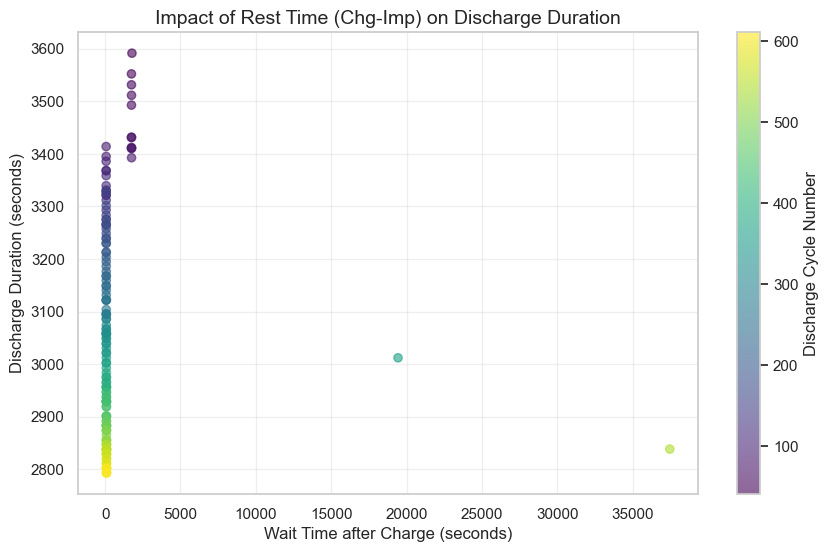

In [38]:
# 시각화 : 방전 시간(Capacity 대용치)과 휴지 시간의 상관관계

plt.figure(figsize=(10, 6))

# 데이터의 흐름(사이클)을 색상(hue)으로 표현하여 열화 진행도를 같이 봅니다.
scatter = plt.scatter(final_mapped['cha_imp'], final_mapped['dis_duration'], 
                      c=final_mapped['dis_t_cycle'], cmap='viridis', alpha=0.6)

plt.colorbar(scatter, label='Discharge Cycle Number')
plt.title('Impact of Rest Time (Chg-Imp) on Discharge Duration', fontsize=14)
plt.xlabel('Wait Time after Charge (seconds)')
plt.ylabel('Discharge Duration (seconds)')
plt.grid(True, alpha=0.3)
plt.show()

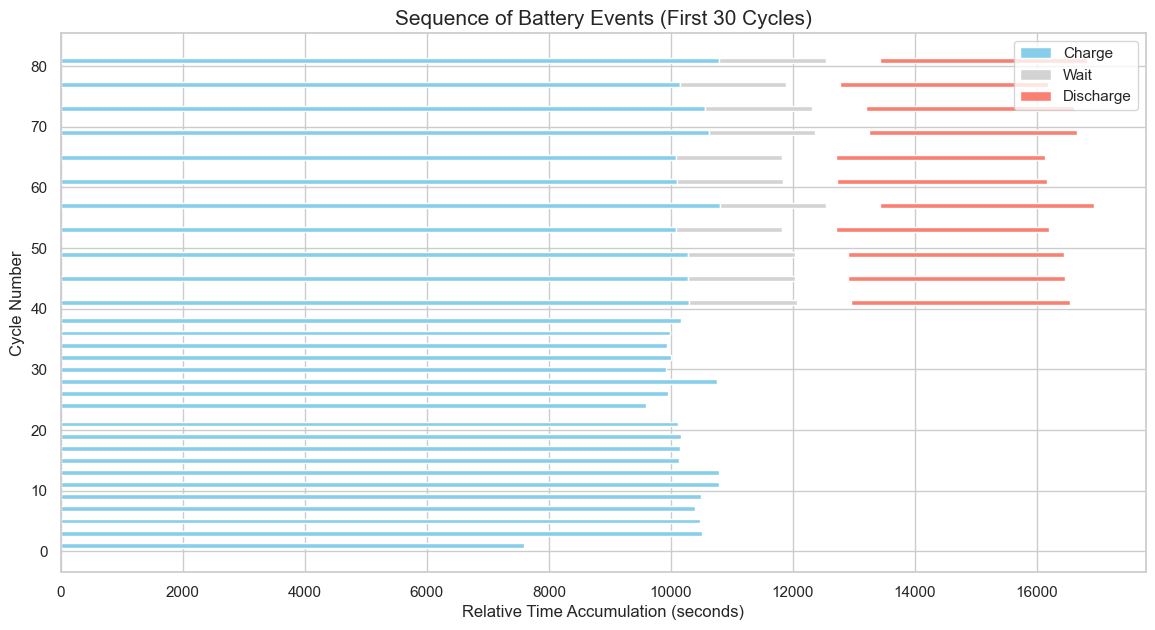

In [44]:
# 시각화 : 전체 실험 타임라인 요약 (Gantt Chart 스타일)


# 상위 30개 사이클만 샘플링해서 보기
sample = final_mapped.head(30)

fig, ax = plt.subplots(figsize=(14, 7))

for i, row in sample.iterrows():
    # 충전 지속 시간
    ax.barh(row['dis_t_cycle'], row['chg_duration'], left=0, color='skyblue', label='Charge' if i==0 else "")
    # 충전-임피던스 대기 시간
    ax.barh(row['dis_t_cycle'], row['cha_imp'], left=row['chg_duration'], color='lightgrey', label='Wait' if i==0 else "")
    # 방전 지속 시간 (시각화를 위해 임의 간격 조정 가능)
    ax.barh(row['dis_t_cycle'], row['dis_duration'], left=row['chg_duration'] + row['cha_imp'] + row['imp_dis'], 
            color='salmon', label='Discharge' if i==0 else "")

plt.title('Sequence of Battery Events (First 30 Cycles)', fontsize=15)
plt.xlabel('Relative Time Accumulation (seconds)')
plt.ylabel('Cycle Number')
plt.legend()
plt.show()

1
1

1

1

1

1

1

1

1

1

1

1

1

1

1

1

1

1
1
# 여기까지 보고 아래는 하려다 말음 (혹시나 아래는 보지마세요 정리안된것임)

1

1

1

1

1

1

1

1

1

1

1

1

1

1

1

1

1

1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1

In [ ]:
import pandas as pd

# 1. 데이터 타입 변환 및 정렬
df_total_B0005['start_time'] = pd.to_datetime(df_total_B0005['start_time'])

# 2. 타입별 'cycle_in_type' 기준 대표 데이터 추출 (중복 제거)
# 각 타입 내의 고유 회차(cycle_in_type)당 가장 먼저 시작된 데이터 1개만 남깁니다.
def get_unique_type_cycle(df, t_type):
    subset = df[df['type'] == t_type].sort_values('start_time')
    # cycle_in_type 기준으로 그룹화하여 첫 번째 행만 추출
    return subset.groupby('cycle_in_type').first().reset_index()

chg_unique = get_unique_type_cycle(df_total_B0005, 'charge')
imp_unique = get_unique_type_cycle(df_total_B0005, 'impedance')
dis_unique = get_unique_type_cycle(df_total_B0005, 'discharge')

# 3. 컬럼명 정리 및 종료 시점 계산
chg_p = chg_unique[['cycle_in_type', 'start_time', 'Time']].rename(
    columns={'cycle_in_type': 'chg_cycle', 'start_time': 'chg_start_time', 'Time': 'chg_duration'}
)
chg_p['chg_end'] = chg_p['chg_start_time'] + pd.to_timedelta(chg_p['chg_duration'], unit='s')

imp_p = imp_unique[['cycle_in_type', 'start_time']].rename(
    columns={'cycle_in_type': 'imp_cycle', 'start_time': 'imp_start_time'}
)

dis_p = dis_unique[['cycle_in_type', 'start_time', 'Time']].rename(
    columns={'cycle_in_type': 'dis_cycle', 'start_time': 'dis_start_time', 'Time': 'dis_duration'}
)

# 4. [자석 매칭] 임피던스 시점을 기준으로 앞뒤 실험 결합
# 시간 순서상 임피던스 직전의 충전과 직후의 방전을 찾습니다.
final = pd.merge_asof(
    imp_p.sort_values('imp_start_time'),
    chg_p.sort_values('chg_end'),
    left_on='imp_start_time', right_on='chg_end',
    direction='backward'
)

final = pd.merge_asof(
    final.sort_values('imp_start_time'),
    dis_p.sort_values('dis_start_time'),
    left_on='imp_start_time', right_on='dis_start_time',
    direction='forward'
)

# 5. [사용자 정의 공식 연산]
# chg_imp = 임피던스 시작 - (충전 시작 + 충전 시간)
final['chg_imp'] = (final['imp_start_time'] - final['chg_end']).dt.total_seconds()

# imp_dis = 방전 시작 - 임피던스 시작
final['imp_dis'] = (final['dis_start_time'] - final['imp_start_time']).dt.total_seconds()

# 6. 최종 컬럼 구성 (요청하신 모든 컬럼 포함)
final_cols = [
    'chg_cycle', 'chg_start_time', 'chg_duration', 
    'imp_cycle', 'imp_start_time', 'chg_imp', 'imp_dis', 
    'dis_cycle', 'dis_start_time', 'dis_duration'
]

# 결과 정리 (NaN 제거 및 중복 방지)
final_result = final[final_cols].dropna(subset=['chg_cycle', 'dis_cycle']).reset_index(drop=True)
final_result[['chg_imp', 'imp_dis']] = final_result[['chg_imp', 'imp_dis']].clip(lower=0)

print(f"--- [완료] cycle_in_type 기반 {len(final_result)}개 세트 통합 ---")
display(final_result.head(20))

In [ ]:

# 1. 방전(Discharge) 요약: 사이클별 방전 종료 시간 추출
dis_summary = df_total_B0005[df_total_B0005['type'] == 'discharge'].groupby('discharge_cycle').agg({
    'start_time': 'first',
    'Time': 'max'
}).reset_index().rename(columns={'Time': 'dis_end_offset', 'start_time': 'dis_start_time'})

# 2. 임피던스(Impedance) 요약: 사이클별 시작 시간 및 '임피던스 전용 사이클 번호' 추출
# 보통 'cycle_in_type' 컬럼이 해당 타입 내에서의 순번을 의미합니다.
imp_summary = df_total_B0005[df_total_B0005['type'] == 'impedance'].groupby('discharge_cycle').agg({
    'start_time': 'first',
    'cycle_in_type': 'first'  # 임피던스 실험 자체의 회차 번호
}).reset_index().rename(columns={
    'start_time': 'imp_start_time',
    'cycle_in_type': 'impedance_cycle'
})

# 3. 사이클 번호를 기준으로 병합 (Inner Join)
cycle_matched = pd.merge(dis_summary, imp_summary, on='discharge_cycle', how='inner')

# 4. 휴지 시간 계산
cycle_matched['gap_seconds'] = (cycle_matched['imp_start_time'] - cycle_matched['dis_start_time']).dt.total_seconds()
cycle_matched['pure_rest_time'] = cycle_matched['gap_seconds'] - cycle_matched['dis_end_offset']

# 5. [요청사항] 첫 번째 행 제거 및 인덱스 초기화
cycle_matched = cycle_matched.iloc[1:].reset_index(drop=True)

# 6. 결과 확인
print("--- 방전 사이클과 임피던스 사이클이 병기된 최종 결과 ---")
display(cycle_matched[['discharge_cycle', 'impedance_cycle', 'dis_start_time','dis_end_offset', 'imp_start_time', 'pure_rest_time']].head(10))

In [ ]:
# 배터리 방전시간은 방전에서 time이 max(방전완료시간)일때 까지고, 
# 임피던스값을 잴때까지의 휴지시간은 방전완료시간부터 다음에오는'start_time이 가장 가까운 임피던스의 값'이 재어진 start_time


# 1. 방전(Discharge) 데이터 정리: 각 사이클별 방전 종료 시간(end_offset) 추출
dis_summary = df_total_B0005[df_total_B0005['type'] == 'discharge'].groupby('discharge_cycle').agg({
    'start_time': 'first',
    'Time': 'max'  # 방전 완료 시간
}).reset_index().rename(columns={'Time': 'dis_end_offset', 'start_time': 'dis_start_time'})

# 2. 임피던스(Impedance) 데이터 정리: 각 사이클별 임피던스 시작 시간 추출
imp_summary = df_total_B0005[df_total_B0005['type'] == 'impedance'].groupby('discharge_cycle').agg({
    'start_time': 'first' # 임피던스 측정 시작 시각
}).reset_index().rename(columns={'start_time': 'imp_start_time'})

# 3. 사이클(discharge_cycle)을 기준으로 두 테이블 병합
# 동일한 사이클 번호를 가진 행끼리 옆으로 붙입니다.
cycle_matched = pd.merge(dis_summary, imp_summary, on='discharge_cycle', how='inner')

# 4. 휴지 시간 계산
# 동일 사이클 내: (임피던스 시작 시각 - 방전 시작 시각) - 방전 지속 시간
cycle_matched['gap_seconds'] = (cycle_matched['imp_start_time'] - cycle_matched['dis_start_time']).dt.total_seconds()
cycle_matched['pure_rest_time'] = cycle_matched['gap_seconds'] - cycle_matched['dis_end_offset']

# cycle_matched 데이터프레임의 첫 번째 행을 제거
cycle_matched = cycle_matched.iloc[1:].reset_index(drop=True)

# 5. 결과 확인
print("--- 동일 사이클 내 방전 종료 ~ 임피던스 시작 휴지 시간 ---")
display(cycle_matched[['discharge_cycle', 'dis_start_time', 'dis_end_offset', 'imp_start_time', 'pure_rest_time']])

In [ ]:
# 방전끝~임피던스 측정시간 사이의 정보량확인
discharge_check['rest_time'].describe().round(2)

In [ ]:
# 방전(discharge) 행과 그 바로 다음 행(주로 impedance)의 시간 차이 계산
temp_df = B0005_timeline.copy()
temp_df['next_start'] = temp_df['start_time'].shift(-1)
temp_df['gap'] = (temp_df['next_start'] - temp_df['start_time']).dt.total_seconds()

# 방전(discharge)이 끝난 시점(5650초 후)부터 다음 실험까지의 순수 대기 시간
# 각 실험별 duration 계산
df_duration = df_total_B0005.groupby('start_time')['Time'].agg(['min', 'max']).reset_index()
df_duration['duration'] = df_duration['max'] - df_duration['min']
# timeline에 붙이기
timeline = df_total_B0005.drop_duplicates('start_time').sort_values('start_time').copy()
timeline = timeline.merge(df_duration[['start_time', 'duration']], on='start_time', how='left')

timeline['next_start'] = timeline['start_time'].shift(-1)
timeline['pure_wait_time'] = (
    (timeline['next_start'] - timeline['start_time']).dt.total_seconds()
    - timeline['duration']
)

# --- discharge 기준만 보고 싶을 때 ---
timeline_dis = timeline[timeline['type'] == 'discharge'].copy()
timeline_dis['next_start'] = timeline_dis['start_time'].shift(-1)
timeline_dis['pure_wait_time'] = (
    (timeline_dis['next_start'] - timeline_dis['start_time']).dt.total_seconds()
    - timeline_dis['duration']
)

# 방전 직후 데이터 샘플 확인
#print(temp_df[temp_df['type'] == 'discharge'][['start_time', 'next_start', 'pure_wait_time']])
print(
    timeline[timeline['type'] == 'discharge']
    [['start_time', 'next_start', 'duration', 'pure_wait_time']]
)

In [ ]:
timeline[['type', 'duration']].groupby('type').describe()

In [ ]:
##### 시각화

# 1. B0005 데이터만 필터링 및 시간순 정렬 (metadata 통합본 사용)
df_b0005_meta = B0005_timeline.copy()
df_b0005_meta = df_b0005_meta.sort_values('start_time')

# 3. 시각화 (Y축: type, X축: start_time)
plt.figure(figsize=(15, 6))

# scatterplot을 활용하여 점으로 표현 (alpha로 투명도 조절하여 겹침 확인)
sns.scatterplot(data=df_b0005_meta, x='start_time', y='type', hue='type', 
                style='type', markers={'charge': 'o', 'discharge': 's', 'impedance': '^'},
                s=50, alpha=0.6)

plt.title('B0005 Experiment Timeline by Test Type', fontsize=16)
plt.xlabel('Experiment Time (start_time)', fontsize=12)
plt.ylabel('Test Type', fontsize=12)
plt.grid(True, axis='x', linestyle='--', alpha=0.5) # X축(시간) 그리드 강조
plt.legend(title='Test Type')
plt.show()

In [ ]:
#@ 파생 생성

# STEP 1. 실험 단위 요약 (df_cycle)

df_cycle = (
    df_total_B0005
    .drop_duplicates('start_time')
    .sort_values('start_time')
    .copy()
)

# 이전 타입
df_cycle['prev_type'] = df_cycle['type'].shift(1)


# STEP 2. 기본 파생 변수

# duration
df_duration = (
    df_total_B0005
    .groupby('start_time')['Time']
    .agg(['min', 'max'])
    .reset_index()
)
df_duration['duration'] = df_duration['max'] - df_duration['min']

df_cycle = df_cycle.merge(
    df_duration[['start_time', 'duration']],
    on='start_time',
    how='left'
)

# pure_wait_time
df_cycle['next_start'] = df_cycle['start_time'].shift(-1)

df_cycle['pure_wait_time'] = (
    (df_cycle['next_start'] - df_cycle['start_time']).dt.total_seconds()
    - df_cycle['duration']
)


# STEP 3. Charge / Discharge 시간 파생

def get_cc_time(df, start_time):
    d = df[df['start_time'] == start_time]
    cc = d[d['Current_measured'] >= 1.45]
    if cc.empty:
        return 0
    return cc['Time'].max() - cc['Time'].min()

def get_dis_time(df, start_time):
    d = df[df['start_time'] == start_time]
    return d['Time'].max() - d['Time'].min()

df_cycle['CC_Time'] = df_cycle.apply(
    lambda x: get_cc_time(df_total_B0005, x['start_time'])
    if x['type'] == 'charge' else np.nan,
    axis=1
)

df_cycle['Dis_Time'] = df_cycle.apply(
    lambda x: get_dis_time(df_total_B0005, x['start_time'])
    if x['type'] == 'discharge' else np.nan,
    axis=1
)


# STEP 4. Impedance 분리

df_imp = df_cycle[df_cycle['type'] == 'impedance'].copy()

df_post_charge = df_imp[df_imp['prev_type'] == 'charge']
df_post_discharge = df_imp[df_imp['prev_type'] == 'discharge']


# STEP 5. Rct Gap (핵심 feature)

df_rct_gap = pd.merge_asof(
    df_post_discharge.sort_values('start_time'),
    df_post_charge.sort_values('start_time'),
    on='start_time',
    direction='backward',
    suffixes=('_dis', '_cha')
)

df_rct_gap['Rct_gap'] = abs(
    df_rct_gap['Rct_cha'] - df_rct_gap['Rct_dis']
)

# STEP 6. 최종 feature 테이블

# discharge 기준으로 feature 구성
df_features = df_cycle[df_cycle['type'] == 'discharge'][[
    'start_time',
    'discharge_cycle',
    'Capacity'
]].copy()

# Rct 매칭
df_rct = df_imp[['start_time', 'Rct']]

df_features = pd.merge_asof(
    df_features.sort_values('start_time'),
    df_rct.sort_values('start_time'),
    on='start_time',
    direction='nearest'
)

# CC time
df_cc = df_cycle[df_cycle['type'] == 'charge'][['start_time', 'CC_Time']]

df_features = pd.merge_asof(
    df_features.sort_values('start_time'),
    df_cc.sort_values('start_time'),
    on='start_time',
    direction='backward'
)

# RUL
df_rul = df_total_B0005[['start_time', 'RUL']].drop_duplicates()

df_features = pd.merge_asof(
    df_features.sort_values('start_time'),
    df_rul.sort_values('start_time'),
    on='start_time',
    direction='nearest'
)

# Rct gap
df_features = pd.merge_asof(
    df_features.sort_values('start_time'),
    df_rct_gap[['start_time', 'Rct_gap']].sort_values('start_time'),
    on='start_time',
    direction='nearest'
)

In [ ]:
# 공통 데이터
df_cycle = df_cycle.sort_values('start_time')
df_imp = df_cycle[df_cycle['type']=='impedance']
df_dis = df_cycle[df_cycle['type']=='discharge']
df_cha = df_cycle[df_cycle['type']=='charge']

df_pc = df_imp[df_imp['prev_type']=='charge']
df_pd = df_imp[df_imp['prev_type']=='discharge']

df_imp_trend = df_imp.drop_duplicates('start_time').sort_values('start_time')
df_imp_trend['Rct_norm'] = df_imp_trend['Rct']/df_imp_trend['Rct'].iloc[0]

global_rct_max = max(df_imp_trend['Rct'].max(), df_rct_gap['Rct_gap'].max())

In [ ]:
def plot_main(period=None, show_gap=True, show_duration=False, zoom=False):

    # --- 필터 ---
    if period:
        s,e = pd.to_datetime(period[0]), pd.to_datetime(period[1])
        f = df_cycle[(df_cycle['start_time']>=s)&(df_cycle['start_time']<=e)]
        g = df_rct_gap[(df_rct_gap['start_time']>=s)&(df_rct_gap['start_time']<=e)]
    else:
        f,g = df_cycle, df_rct_gap

    dis = f[f['type']=='discharge']
    cha = f[f['type']=='charge']
    imp = f[f['type']=='impedance']
    pc  = imp[imp['prev_type']=='charge']
    pd_ = imp[imp['prev_type']=='discharge']

    fig, ax1 = plt.subplots(figsize=(16,8))

    # --- LEFT ---
    if show_duration:
        ax1.bar(cha['start_time'], cha['CC_Time'], alpha=0.3, width=0.2)
        ax1.bar(dis['start_time'], dis['Dis_Time'], alpha=0.2, width=0.2)
        ax1.set_ylabel('Duration')
    else:
        ax1.bar(dis['start_time'], dis['Capacity'], alpha=0.4)
        if not cha.empty:
            ax1.bar(cha['start_time'], [dis['Capacity'].max()*1.1]*len(cha), alpha=0.15, width=0.3)
        ax1.set_ylabel('Capacity')

    ax2 = ax1.twinx()

    # --- Rct ---
    ax2.plot(pc['start_time'], pc['Rct'], marker='o', linewidth=1.5)
    ax2.plot(pd_['start_time'], pd_['Rct'], linestyle='--', marker='x', linewidth=1.5)

    # --- 전체 트렌드 ---
    ax2.plot(imp['start_time'], imp['Rct'], linestyle='--', alpha=0.3)

    # --- gap ---
    if show_gap:
        ax2.plot(g['start_time'], g['Rct_gap'], marker='s', linewidth=2)

    ax2.set_ylim(0, global_rct_max*1.2)
    ax1.grid(True, alpha=0.2)
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

In [ ]:
plot_main()

In [ ]:
plot_main(period=('2008-04-18','2008-04-20'))

In [ ]:
plot_main(show_duration=True)

In [ ]:
plot_main(period=('2008-04-17','2008-04-22'))
plot_main(period=('2008-05-24','2008-05-27'))

In [ ]:
def plot_resistance():
    fig, ax1 = plt.subplots(figsize=(12,6))
    ax1.plot(df_imp_trend['start_time'], df_imp_trend['Re'], marker='o')
    ax2 = ax1.twinx()
    ax2.plot(df_imp_trend['start_time'], df_imp_trend['Rct'], linestyle='--')
    ax2.plot(df_imp_trend['start_time'], df_imp_trend['Rct_norm'], linestyle=':')
    plt.xticks(rotation=30); plt.tight_layout(); plt.show()

In [ ]:
plot_resistance()

In [ ]:
def plot_resistance():
    fig, ax1 = plt.subplots(figsize=(12,6))

    # --- Re (왼쪽 축) ---
    ax1.plot(
        df_imp_trend['start_time'],
        df_imp_trend['Re'],
        marker='o',
        label='Re'
    )
    ax1.set_ylabel('Re (Ohm)')

    # --- Rct / Rct_norm (오른쪽 축) ---
    ax2 = ax1.twinx()

    ax2.plot(
        df_imp_trend['start_time'],
        df_imp_trend['Rct'],
        linestyle='--',
        label='Rct'
    )

    ax2.plot(
        df_imp_trend['start_time'],
        df_imp_trend['Rct_norm'],
        linestyle=':',
        label='Rct (Normalized)'
    )

    ax2.set_ylabel('Rct / Rct_norm')

    # --- 공통 ---
    ax1.set_title('Resistance Trend (Re vs Rct)')
    ax1.tick_params(axis='x', rotation=30)

    # 범례 합치기
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

    ax1.grid(True, alpha=0.2)

    plt.tight_layout()
    plt.show()

In [ ]:
plot_resistance()

In [ ]:
#@ Feature 전체 흐름

fig, ax1 = plt.subplots(figsize=(16, 8))

# --- Capacity (왼쪽 축) ---
ax1.plot(
    df_features['start_time'],
    df_features['Capacity'],
    marker='o',
    label='Capacity'
)
ax1.set_ylabel('Capacity (Ah)')

# --- CC Time ---
ax1.plot(
    df_features['start_time'],
    df_features['CC_Time'],
    linestyle='--',
    label='CC Time'
)

# --- 오른쪽 축 (Rct, Rct_gap) ---
ax2 = ax1.twinx()

ax2.plot(
    df_features['start_time'],
    df_features['Rct'],
    color='red',
    marker='x',
    label='Rct'
)

ax2.plot(
    df_features['start_time'],
    df_features['Rct_gap'],
    color='green',
    linestyle=':',
    label='Rct Gap'
)

ax1.set_xlabel('Time')
ax2.set_ylabel('Resistance')

ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.title('Battery Feature Trends (Capacity, CC Time, Rct, Rct Gap)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
#@ Feature 간 관계 (상관 구조 확인)

cols = ['Capacity', 'Rct', 'CC_Time', 'Rct_gap', 'RUL']
corr = df_features[cols].corr(method='spearman')

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Feature Correlation (Spearman)')
plt.show()

In [ ]:
#@ RUL 기준 Feature 분포 (모델 직결)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Rct vs RUL
axes[0].scatter(df_features['RUL'], df_features['Rct'])
axes[0].set_title('Rct vs RUL')

# CC Time vs RUL
axes[1].scatter(df_features['RUL'], df_features['CC_Time'])
axes[1].set_title('CC Time vs RUL')

# Rct_gap vs RUL
axes[2].scatter(df_features['RUL'], df_features['Rct_gap'])
axes[2].set_title('Rct Gap vs RUL')

for ax in axes:
    ax.set_xlabel('RUL')
    ax.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
#@ 시간 기반 패턴 분해 (운용 영향 확인) pure_wait_time / duration 영향 확인

fig, ax1 = plt.subplots(figsize=(14, 6))

# duration
ax1.plot(df_cycle['start_time'], df_cycle['duration'], label='Duration')

# wait time
ax1.plot(df_cycle['start_time'], df_cycle['pure_wait_time'], label='Wait Time')

ax1.set_ylabel('Time (sec)')
ax1.legend()

# Rct overlay
ax2 = ax1.twinx()
ax2.plot(df_cycle['start_time'], df_cycle['Rct'], color='red', alpha=0.3, label='Rct')
ax2.set_ylabel('Rct')

plt.title('Operation Pattern vs Resistance')
plt.xticks(rotation=45)
plt.show()

In [ ]:
#@ Rct Gap 검증 (핵심 feature sanity check)

plt.figure(figsize=(14, 5))

plt.plot(
    df_rct_gap['start_time'],
    df_rct_gap['Rct_gap'],
    marker='o'
)

plt.title('Rct Gap Over Time')
plt.ylabel('Rct Gap')
plt.xlabel('Time')
plt.grid(True)
plt.show()

In [ ]:
#@Feature vs Capacity 직접 관계 : 모델 없이도 설명력 확인

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(df_features['Rct'], df_features['Capacity'])
axes[0].set_title('Rct vs Capacity')

axes[1].scatter(df_features['CC_Time'], df_features['Capacity'])
axes[1].set_title('CC Time vs Capacity')

axes[2].scatter(df_features['Rct_gap'], df_features['Capacity'])
axes[2].set_title('Rct Gap vs Capacity')

for ax in axes:
    ax.set_xlabel('Feature')
    ax.set_ylabel('Capacity')
    ax.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
##@
# discharge / charge
df_dis = df_cycle[df_cycle['type'] == 'discharge']
df_cha = df_cycle[df_cycle['type'] == 'charge']

fig, ax1 = plt.subplots(figsize=(16, 8))

# --- (A) Capacity (왼쪽 축) ---
ax1.bar(
    df_dis['start_time'],
    df_dis['Capacity'],
    alpha=0.4,
    label='Discharge Capacity'
)

# charge 위치 표시 (단순 마커용)
if not df_cha.empty:
    ax1.bar(
        df_cha['start_time'],
        [df_dis['Capacity'].max() * 1.1] * len(df_cha),
        alpha=0.15,
        width=0.3,
        label='Charge Cycle'
    )

ax1.set_xlabel('Timeline')
ax1.set_ylabel('Capacity (Ah)')
ax1.legend(loc='upper left')


# --- (B) Rct (오른쪽 축) ---
ax2 = ax1.twinx()

# 충전 후 impedance
ax2.plot(
    df_post_charge['start_time'],
    df_post_charge['Rct'],
    marker='o',
    linewidth=1.5,
    label='Post-Charge Rct'
)

# 방전 후 impedance
ax2.plot(
    df_post_discharge['start_time'],
    df_post_discharge['Rct'],
    linestyle='--',
    marker='x',
    linewidth=1.5,
    label='Post-Discharge Rct'
)

ax2.set_ylabel('Rct (Ohm)')
ax2.legend(loc='upper right')


# ================================
# 3. 마무리
# ================================
plt.title('B0005: Capacity vs Logic-based Rct (Refactored)')
plt.grid(True, axis='y', alpha=0.2)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
##@

# ================================
# 0. 기간 설정
# ================================
start_date = '2008-04-18'
end_date   = '2008-04-20'


# ================================
# 1. df_cycle 기준 필터링
# ================================
mask = (df_cycle['start_time'] >= start_date) & (df_cycle['start_time'] <= end_date)
df_zoom = df_cycle.loc[mask].copy()


# ================================
# 2. 타입별 분리
# ================================
df_z_dis = df_zoom[df_zoom['type'] == 'discharge']
df_z_cha = df_zoom[df_zoom['type'] == 'charge']
df_z_imp = df_zoom[df_zoom['type'] == 'impedance']

# impedance 로직 분리
df_z_post_charge = df_z_imp[df_z_imp['prev_type'] == 'charge']
df_z_post_discharge = df_z_imp[df_z_imp['prev_type'] == 'discharge']


# ================================
# 3. 시각화
# ================================
fig, ax1 = plt.subplots(figsize=(16, 8))

# --- (A) Capacity ---
ax1.bar(
    df_z_dis['start_time'],
    df_z_dis['Capacity'],
    alpha=0.5,
    width=0.1,
    label='Discharge Capacity'
)

# charge 위치 표시
if not df_z_cha.empty:
    ax1.bar(
        df_z_cha['start_time'],
        [df_z_dis['Capacity'].max() * 1.1] * len(df_z_cha),
        alpha=0.2,
        width=0.08,
        label='Charge Cycle'
    )

ax1.set_xlabel('Timeline')
ax1.set_ylabel('Capacity (Ah)')
ax1.legend(loc='upper left')


# --- (B) Rct ---
ax2 = ax1.twinx()

ax2.plot(
    df_z_post_charge['start_time'],
    df_z_post_charge['Rct'],
    marker='o',
    linewidth=2,
    label='Post-Charge Rct'
)

ax2.plot(
    df_z_post_discharge['start_time'],
    df_z_post_discharge['Rct'],
    linestyle='--',
    marker='x',
    linewidth=2,
    label='Post-Discharge Rct'
)

ax2.set_ylabel('Rct (Ohm)')
ax2.legend(loc='upper right')


# ================================
# 4. 마무리
# ================================
plt.title(f'B0005 Zoom-in: {start_date} ~ {end_date} (Refactored)')
plt.grid(True, axis='both', alpha=0.2)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


In [ ]:
##@



# ================================
# 3. 시각화
# ================================
fig, ax1 = plt.subplots(figsize=(16, 9))

# --- (A) 시간 기반 지표 ---
# CC 충전 시간
ax1.bar(
    df_cha['start_time'],
    df_cha['CC_Time'],
    alpha=0.3,
    width=0.4,
    label='CC Charge Duration (sec)'
)

# 방전 시간
ax1.bar(
    df_dis['start_time'],
    df_dis['Dis_Time'],
    alpha=0.2,
    width=0.4,
    label='Discharge Duration (sec)'
)

ax1.set_xlabel('Timeline')
ax1.set_ylabel('Duration (sec)')
ax1.legend(loc='upper left')


# ================================
# 4. Rct 계열 (오른쪽 축)
# ================================
ax2 = ax1.twinx()

# 전체 Rct 흐름 (impedance 전체)
df_imp_plot = df_imp.sort_values('start_time')

ax2.plot(
    df_imp_plot['start_time'],
    df_imp_plot['Rct'],
    linestyle='--',
    alpha=0.3,
    label='Overall Rct Trend'
)

# Rct Gap (핵심 feature)
ax2.plot(
    df_rct_gap['start_time'],
    df_rct_gap['Rct_gap'],
    marker='s',
    markersize=4,
    label='Rct Gap'
)

ax2.set_ylabel('Rct (Ohm)')

# 축 범위 정렬
max_rct = max(
    df_imp_plot['Rct'].max(),
    df_rct_gap['Rct_gap'].max()
)
ax2.set_ylim(0, max_rct * 1.2)

ax2.legend(loc='upper right')


# ================================
# 5. 마무리
# ================================
plt.title('B0005: Health Indicators (Refactored Features)')
plt.grid(True, axis='y', alpha=0.2)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. 구간 설정
first_period = ('2008-04-17', '2008-04-22')  # 전반부
last_period  = ('2008-05-24', '2008-05-27')  # 후반부

# 2. 요약 데이터 생성 및 기본 지표 계산

def get_duration(df_total, start_time, d_type):
    data = df_total[df_total['start_time'] == start_time]
    if d_type == 'charge':
        cc_phase = data[data['Current_measured'] >= 1.45]
        return cc_phase['Time'].max() - cc_phase['Time'].min() if not cc_phase.empty else 0
    else:
        return data['Time'].max() - data['Time'].min()


# [핵심 수정] Rct Gap (시간 기반 매칭)
########df_imp_total = df_sum[df_sum['type'] == 'impedance'].copy().sort_values('start_time')

############################df_pc = df_imp_total[df_imp_total['prev_type'] == 'charge'].copy()
############################df_pd = df_imp_total[df_imp_total['prev_type'] == 'discharge'].copy()

# [수정 1] 시간축 데이터 타입을 통일 (그래프 끊김 방지)
df_sum['start_time'] = pd.to_datetime(df_sum['start_time'])
############################df_rct_gap_all['start_time'] = pd.to_datetime(df_rct_gap_all['start_time'])

# 3. 그래프 그리기
fig, (ax_f, ax_l) = plt.subplots(1, 2, figsize=(18, 8), sharey=True)
periods = [first_period, last_period]
axes = [ax_f, ax_l]
titles = ["First Period (Initial)", "Last Period (Degraded)"]

# [수정 2] Y축 범위를 결정하기 위해 전체 Rct의 최대값 미리 파악
global_rct_max = df_sum['Rct'].max()

for ax, period, title in zip(axes, periods, titles):
    # 기간 필터링 (Timestamp 형식으로 비교)
    mask_p = (df_sum['start_time'] >= pd.to_datetime(period[0])) & (df_sum['start_time'] <= pd.to_datetime(period[1]))
    mask_g = (df_rct_gap_all['start_time'] >= pd.to_datetime(period[0])) & (df_rct_gap_all['start_time'] <= pd.to_datetime(period[1]))
    
    df_p = df_sum.loc[mask_p]
    df_g = df_rct_gap_all.loc[mask_g]
    
    # --- 왼쪽 축: 시간 지표 (Bar) ---
    df_c = df_p[df_p['type'] == 'charge']
    df_d = df_p[df_p['type'] == 'discharge']
    ax.bar(df_c['start_time'], df_c['CC_Time'], color='blue', alpha=0.3, width=0.1, label='CC Charge')
    ax.bar(df_d['start_time'], df_d['Dis_Time'], color='red', alpha=0.2, width=0.1, label='Discharge')
    
    # --- 오른쪽 축: 저항 지표 (Line) ---
    ax_tw = ax.twinx()
    
    # [수정 3] Overall Rct Trend (회색 선) - 배경으로 먼저 그리기
    df_i = df_p[df_p['type'] == 'impedance']
    ax_tw.plot(df_i['start_time'], df_i['Rct'], color='gray', alpha=0.3, linestyle='--', label='Overall Rct')
    
    # 1:1 매칭된 Gap 데이터 시각화 (초록색 점/선)
    if 'df_g' in locals() and not df_g.empty:
        ax_tw.plot(df_g['start_time'], df_g['Rct_gap'], color='green', marker='s', 
                   markersize=8, linewidth=2, label='Rct Gap', zorder=5)
    
    # [수정 4] Y축 범위를 Rct 전체 트렌드에 맞춤 (그래야 회색 선이 보임)
    # 만약 Gap을 더 강조하고 싶다면 global_rct_max 대신 특정 배수를 사용하세요.
    ax_tw.set_ylim(0, global_rct_max * 1.2)
    
    # 포맷팅
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    if ax == ax_f:
        ax.set_ylabel('Duration (Seconds)')
    
    # [수정 5] 오른쪽 축 라벨은 마지막 서브플롯에만 표시하거나 양쪽 다 표시
    ax_tw.set_ylabel('Resistance (Ohm)')
    
    ax.grid(True, alpha=0.2)

plt.suptitle('B0005: Initial vs Degraded Comparison (Verified Trends)', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:

# 1. 시각화용 요약 데이터 <df=sum>

# 2. 지표 추출 함수: CC Time (정전류 충전 시간) 계산
# 충전 전류가 약 1.5A로 유지되는 시간을 각 충전 사이클마다 계산
def get_cc_time(df_total, start_time):
    # 해당 사이클의 충전 데이터만 필터링
    c_data = df_total[df_total['start_time'] == start_time]
    # 전류가 1.5A 근처(예: 1.45A 이상)인 데이터의 시간차 계산
    cc_phase = c_data[c_data['Current_measured'] >= 1.45]
    if not cc_phase.empty:
        return cc_phase['Time'].max() - cc_phase['Time'].min()
    return 0



# 3. 타입별 데이터 분할
df_pc_rct = df_imp[df_imp['prev_type'] == 'charge']      # Post-Charge Rct
df_pd_rct = df_imp[df_imp['prev_type'] == 'discharge']   # Post-Discharge Rct

# 4. 시각화 (3단 구성)
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 12), sharex=True)

# (A) Post-Charge Rct (가장 민감한 노화 지표)
ax1.plot(df_pc_rct['start_time'], df_pc_rct['Rct'], 'r-o', markersize=4, label='Post-Charge Rct')
ax1.set_ylabel('Rct (Ohm)', color='red')
ax1.set_title('Indicator 1: Charge Transfer Resistance (Rct) Growth', fontsize=13)
ax1.grid(True, alpha=0.3)

# (B) 저항 차이 (충전후 vs 방전후 편차 - 내부 불안정성)
ax2.plot(df_rct_gap_all['start_time'], df_rct_gap_all['Rct_gap'], 'g--x', markersize=4, label='|PostCharge - PostDischarge|')

ax2.set_ylabel('Delta Rct (Ohm)', color='green')
ax2.set_title('Indicator 2: Rct Gap (Internal Instability)', fontsize=13)
ax2.grid(True, alpha=0.3)

# (C) 정전류(CC) 충전 시간 (운용 성능 지표)
df_cc = df_sum[df_sum['type'] == 'charge'].dropna(subset=['CC_Time'])
ax3.plot(df_cc['start_time'], df_cc['CC_Time'], 'b-s', markersize=4, label='CC Charging Time')
ax3.set_ylabel('Time (sec)', color='blue')
ax3.set_title('Indicator 3: CC Mode Duration (Directly linked to Capacity)', fontsize=13)
ax3.grid(True, alpha=0.3)

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt

# 1. 임피던스 데이터만 추출하여 시간순 정렬
df_imp_trend = df_total_B0005[df_total_B0005['type'] == 'impedance'].drop_duplicates('start_time').sort_values('start_time')

fig, ax1 = plt.subplots(figsize=(12, 6))

# --- 첫 번째 축: Re (오믹 저항) ---
color_re = 'tab:blue'
ax1.set_xlabel('Timeline (start_time)')
ax1.set_ylabel('Electrolyte Resistance (Re, Ohms)', color=color_re)
ax1.plot(df_imp_trend['start_time'], df_imp_trend['Re'], color=color_re, marker='o', markersize=4, label='Re (Electrolyte)')
ax1.tick_params(axis='y', labelcolor=color_re)

# --- 두 번째 축: Rct (전하 전달 저항) ---
ax2 = ax1.twinx() # x축 공유
color_rct = 'tab:red'
ax2.set_ylabel('Charge Transfer Resistance (Rct, Ohms)', color=color_rct)
ax2.plot(df_imp_trend['start_time'], df_imp_trend['Rct'], color=color_rct, marker='x', markersize=4, linestyle='--', label='Rct (Surface)')
ax2.tick_params(axis='y', labelcolor=color_rct)

# 저항증가율???
df_imp_trend['Rct_norm'] = df_imp_trend['Rct'] / df_imp_trend['Rct'].iloc[0]

# --- 그래프 꾸미기 ---
plt.title('B0005: Evolution of Internal Resistance Components (Re vs Rct)', fontsize=15)
ax1.grid(True, alpha=0.3)
fig.tight_layout()
plt.xticks(rotation=30)
plt.show()

In [ ]:
print(df_sum.columns)

In [ ]:
### 그래프 1 (시간 + Rct_gap)

fig, ax1 = plt.subplots(figsize=(16, 9))

# --- 시간 ---
ax1.bar(df_cha['start_time'], df_cha['CC_Time'], alpha=0.3)
ax1.bar(df_dis['start_time'], df_dis['Dis_Time'], alpha=0.3)
ax1.set_ylabel('Duration')

# --- Rct ---
ax2 = ax1.twinx()
ax2.plot(df_imp_plot['start_time'], df_imp_plot['Rct'], linestyle='--')
ax2.set_ylabel('Rct')

# --- Rct_gap 전용 축 ---
ax3 = ax1.twinx()

# 축 위치 이동 (핵심)
ax3.spines["right"].set_position(("outward", 60))

ax3.plot(df_rct_gap_all['start_time'], df_rct_gap_all['Rct_gap'], marker='o')
ax3.set_ylabel('Rct_gap')

plt.show()

In [ ]:
##### 그래프 2 (Re / Rct / Rct_norm)
df_imp_trend = df_total_B0005[
    df_total_B0005['type'] == 'impedance'
].drop_duplicates('start_time').sort_values('start_time')

# 정규화
df_imp_trend['Rct_norm'] = df_imp_trend['Rct'] / df_imp_trend['Rct'].iloc[0]

fig, ax1 = plt.subplots(figsize=(12, 6))

# --- Re ---
ax1.plot(
    df_imp_trend['start_time'],
    df_imp_trend['Re'],
    marker='o',
    label='Re'
)
ax1.set_ylabel('Re (Ohm)')

# --- Rct ---
ax2 = ax1.twinx()
ax2.plot(
    df_imp_trend['start_time'],
    df_imp_trend['Rct'],
    linestyle='--',
    marker='x',
    label='Rct'
)
ax2.set_ylabel('Rct (Ohm)')

# --- Rct_norm (같이 그리기) ---
ax2.plot(
    df_imp_trend['start_time'],
    df_imp_trend['Rct_norm'],
    linestyle=':',
    label='Rct_norm'
)

ax1.set_xlabel('start_time')
plt.title('Internal Resistance Evolution')

ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 모든 실험 타입을 시간순으로 정렬 (B0005 전체 데이터 기준)
# 시계열 데이터를 파일 단위로 요약한 메타데이터(df_total_B0005 생성 전의 원본 리스트 형태)가 필요합니다.
# 여기서는 df_total_B0005에서 중복되지 않는 실험 시작점들만 뽑아서 확인합니다.
timeline = df_total_B0005.drop_duplicates('start_time').sort_values('start_time').copy()

# 2. 직전 실험 타입(Prev_Type) 컬럼 생성
timeline['prev_type'] = timeline['type'].shift(1)

# 3. 임피던스 데이터만 필터링한 뒤, 직전 타입에 따라 분류
impedance_only = timeline[timeline['type'] == 'impedance'].copy()

# 'charge' 직후에 온 임피던스 -> 진짜 Post-Charge
df_real_post_charge = impedance_only[impedance_only['prev_type'] == 'charge']

# 'discharge' 직후에 온 임피던스 -> 진짜 Post-Discharge
df_real_post_discharge = impedance_only[impedance_only['prev_type'] == 'discharge']

# 4. 확인 출력
print(f"총 임피던스 개수: {len(impedance_only)}")
print(f"충전 후(Post-Charge) 개수: {len(df_real_post_charge)}")
print(f"방전 후(Post-Discharge) 개수: {len(df_real_post_discharge)}")

# --- 이제 이 데이터로 다시 시각화 ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Re 그래프
ax1.plot(df_real_post_charge['start_time'], df_real_post_charge['Re'], 'o-', label='Real Post-Charge Re')
ax1.plot(df_real_post_discharge['start_time'], df_real_post_discharge['Re'], 'x--', label='Real Post-Discharge Re')
ax1.legend(); ax1.set_title("Corrected Resistance Trend (Logic-based Separation)")

# Rct 그래프
ax2.plot(df_real_post_charge['start_time'], df_real_post_charge['Rct'], 'o-', color='red', label='Real Post-Charge Rct')
ax2.plot(df_real_post_discharge['start_time'], df_real_post_discharge['Rct'], 'x--', color='orange', label='Real Post-Discharge Rct')
ax2.legend(); ax2.set_xlabel("Timeline")

plt.show()

In [ ]:
##### 1. 방전 전압 강하 (Voltage Drop) 곡선
# 배터리가 노화될수록 저항 때문에 초기 전압이 툭 떨어지고(IR Drop), 전압이 종지 전압(2.7V)까지 도달하는 속도가 빨라집니다.

def plot_discharge_curves(df, cycles_to_plot=[10, 50, 100, 160]):
    plt.figure(figsize=(12, 7))
    
    # 방전 데이터만 미리 필터링
    discharge_df = df[df['type'] == 'discharge']
    
    for cyc in cycles_to_plot:
        # 1. 수정: 'cycle' 대신 통합 시 만든 'cycle_in_type' 사용
        cycle_data = discharge_df[discharge_df['cycle_in_type'] == cyc]
        
        if not cycle_data.empty:
            # 2. 수정: 'start_time' 대신 시계열 내부의 'Time' 컬럼 사용
            # Time이 0부터 시작하지 않을 경우를 대비해 min을 빼줌
            relative_time = cycle_data['Time'] - cycle_data['Time'].min()
            
            # 3. 정렬 확인: 시계열 순서대로 그려지도록 정렬
            cycle_data = cycle_data.sort_values('Time')
            
            plt.plot(relative_time, cycle_data['Voltage_measured'], label=f'Cycle {cyc}')
    
    plt.axhline(y=2.7, color='r', linestyle='--', label='End of Discharge (2.7V)')
    plt.title('B0005 Discharge Voltage Decay (Corrected)', fontsize=14)
    plt.xlabel('Time (sec)')
    plt.ylabel('Voltage (V)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# 실행
plot_discharge_curves(df_total_B0005)

In [ ]:
##### 2. 방전 전압 강하 (Voltage Drop) 곡선
# 배터리가 노화될수록 저항 때문에 초기 전압이 툭 떨어지고(IR Drop), 전압이 종지 전압(2.7V)까지 도달하는 속도가 빨라집니다.
#충전 전류 곡선 (CC-CV 전환 확인)
#배터리가 노화될수록 저항 증가로 인해 일정한 전류로 충전하는 CC 구간이 짧아지고, 전류를 줄이며 충전하는 CV 구간이 길어지는 현상을 시각화합니다.

def plot_cc_cv_transition(df, cycles_to_plot=[10, 80, 160]):
    plt.figure(figsize=(10, 6))
    
    # 충전 데이터만 필터링
    charge_df = df[df['type'] == 'charge']
    
    for cyc in cycles_to_plot:
        # 통합 시 생성한 cycle_in_type 사용
        cycle_data = charge_df[charge_df['cycle_in_type'] == cyc]
        
        if not cycle_data.empty:
            # 시간순 정렬 및 상대 시간 계산
            cycle_data = cycle_data.sort_values('Time')
            relative_time = cycle_data['Time'] - cycle_data['Time'].min()
            
            # 충전 시 전류 측정값 (Current_measured)
            plt.plot(relative_time, cycle_data['Current_measured'], label=f'Cycle {cyc}')
    
    plt.title('B0005 Charging Current (CC to CV Transition)', fontsize=14)
    plt.xlabel('Time (sec)')
    plt.ylabel('Current (A)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# 실행
plot_cc_cv_transition(df_total_B0005)

In [ ]:
# 임피던스 데이터 한 줄만 출력해서 컬럼명과 값의 형태 확인
print(df_total_B0005[df_total_B0005['type'] == 'impedance'].iloc[0])

In [ ]:
##### 3. 나이퀴스트 선도 (Nyquist Plot)
# 임피던스 데이터의 정수입니다. X축을 실수부($Re$), Y축을 허수부($-Im$)로 그리면 반원이 나타납니다. 배터리가 늙을수록 이 반원이 오른쪽으로 밀려나고 크기가 커집니다.

import matplotlib.pyplot as plt

def plot_nyquist(df, cycles_to_plot=[40, 100, 160]):
    plt.figure(figsize=(8, 8))
    
    # 임피던스 데이터만 필터링
    imp_df = df[df['type'] == 'impedance']
    
    for cyc in cycles_to_plot:
        # 해당 순번의 임피던스 데이터 추출
        cycle_data = imp_df[imp_df['cycle_in_type'] == cyc]
        
        if not cycle_data.empty:
            # Battery_impedance 컬럼이 복소수(complex) 타입인 경우 실수/허수 추출
            # 만약 데이터가 문자열 형태라면 .apply(complex)를 먼저 해줘야 할 수도 있습니다.
            z = cycle_data['Battery_impedance']
            
            real = z.apply(lambda x: x.real if hasattr(x, 'real') else ast.literal_eval(x).real)
            imag = z.apply(lambda x: x.imag if hasattr(x, 'imag') else ast.literal_eval(x).imag)
            
            # 나이퀴스트 선도: X축(실수), Y축(-허수)
            plt.plot(real, -imag, marker='o', markersize=4, alpha=0.7, label=f'Cycle {cyc}')
            
            # 시작점(고주파) 강조
            plt.scatter(real.iloc[0], -imag.iloc[0], color='black', s=25, zorder=5)
    
    plt.title('B0005 Nyquist Plot (from Battery_impedance)', fontsize=14)
    plt.xlabel('Real Resistance (Z\', Ohms)')
    plt.ylabel('-Imaginary Resistance (-Z\'\', Ohms)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 비율 1:1 유지
    plt.axis('equal') 
    plt.show()

# 실행
plot_nyquist(df_total_B0005)

In [ ]:
df_features = df_total_B0005[df_total_B0005['type'] == 'discharge'][
    ['discharge_cycle', 'start_time', 'Capacity']
].drop_duplicates()

# Rct (가장 가까운 impedance 매칭 필요)
df_rct = df_imp_trend[['start_time', 'Rct']]

df_features = pd.merge_asof(
    df_features.sort_values('start_time'),
    df_rct.sort_values('start_time'),
    on='start_time',
    direction='nearest'
)

# CC Time
df_cc = df_sum[df_sum['type'] == 'charge'][['start_time', 'CC_Time']]

df_features = pd.merge_asof(
    df_features.sort_values('start_time'),
    df_cc.sort_values('start_time'),
    on='start_time',
    direction='backward'
)

# RUL
df_rul = df_total_B0005[['start_time', 'RUL']].drop_duplicates()

df_features = pd.merge_asof(
    df_features.sort_values('start_time'),
    df_rul.sort_values('start_time'),
    on='start_time',
    direction='nearest'
)

# 배터리별type별 나눠서 12개 -> 이를 type별로 합침 -> 이후 이 것들의 흐름을 비교 또는 합쳐서 분석하기

# 배터리별type별 12개를 나눠서 csv파일에 meta 조인하기

In [ ]:
# 'B0005', 'B0006', 'B0007', 'B0018' 배터리 대상으로 충전 / 방전 / 임피던스별 data 구성하기
# SOH EOL RUL cycle 파생

# 대상 배터리 ID 리스트
target_battery_ids = ['B0005', 'B0006', 'B0007', 'B0018']

# 데이터 저장할 폴더 경로
data_folder = "../../dataset/data"

# 데이터를 쌓아두기 위한 저장소(Dictionary) 생성
collected_data = {}


### 각 배터리별 EOL 사이클 번호를 먼저 파악 (RUL 계산용)
# SOH 80% 기준을 찾기 위해 메타데이터(df)에서 미리 계산
eol_dict = {}
for b_id in target_battery_ids:
    b_meta = df[(df['battery_id'] == b_id) & (df['type'] == 'discharge')].copy()
    if not b_meta.empty:
        initial_cap = b_meta['Capacity'].iloc[0] # 첫 번째 방전 용량
        # SOH 80% 이하인 첫 번째 행의 인덱스(순번) 찾기
        eol_idx = np.where((b_meta['Capacity'] / initial_cap) * 100 <= 80)[0]
        eol_dict[b_id] = eol_idx[0] + 1 if len(eol_idx) > 0 else np.nan

for battery_id in target_battery_ids:
    # 시간순 정렬 (매칭 오류 방지)
    filtered_df = df[df['battery_id'] == battery_id].sort_values('start_time')
    cycle_counters = {'charge': 1, 'discharge': 1, 'impedance': 1}
    
    # 기준 용량 정의 (해당 배터리의 첫 번째 방전 용량)
    dis_rows = filtered_df[filtered_df['type'] == 'discharge']
    first_cap = dis_rows['Capacity'].iloc[0] if not dis_rows.empty else None

    for _, row in filtered_df.iterrows():
        file_path = os.path.join(data_folder, row['filename'])

        if os.path.exists(file_path):
            temp_df = pd.read_csv(file_path)
            d_type = row['type']
            current_cycle = cycle_counters[d_type]

            # --- [1단계: 파생 변수 로직 정의] ---
            # SOH 정의: 오직 discharge 타입일 때만 해당 사이클의 용량으로 계산
            if d_type == 'discharge' and first_cap and pd.notnull(row['Capacity']):
                soh_val = (row['Capacity'] / first_cap) * 100
            else:
                soh_val = np.nan # 다른 타입은 우선 NaN 처리
            
            # EOL 정의: 미리 계산된 eol_dict 이용
            eol_val = eol_dict.get(battery_id)
            
            # RUL 정의: (사망 사이클 - 현재 사이클)
            rul_val = (eol_val - current_cycle) if pd.notnull(eol_val) else np.nan
            if pd.notnull(rul_val): rul_val = max(0, rul_val)

            # --- [2단계: 데이터프레임 열 추가] ---
            temp_df['start_time'] = row['start_time']
            temp_df['battery_id'] = battery_id
            temp_df['type'] = d_type
            temp_df['ambient_temperature'] = row['ambient_temperature']
            
            temp_df['cycle'] = current_cycle
            temp_df['SOH'] = soh_val  # 정의된 값 주입
            temp_df['EOL_cycle'] = eol_val
            temp_df['RUL'] = rul_val

            # 타입별 특화 데이터 추가
            if d_type == 'discharge':
                temp_df['Capacity'] = row['Capacity']
            elif d_type == 'impedance':
                temp_df['Re'] = row['Re']
                temp_df['Rct'] = row['Rct']

            # 카운터 증가 및 저장
            cycle_counters[d_type] += 1
            key = f"df_{d_type}_{battery_id}"
            if key not in collected_data:
                collected_data[key] = []
            collected_data[key].append(temp_df)
        else:
            print(f"[누락 파일] {file_path}")

# --- [3단계: 데이터 통합 및 결측치 전파] ---
for key, df_list in collected_data.items():
    combined_df = pd.concat(df_list, ignore_index=True)
    
    # SOH 전파: discharge 파일들 사이의 간극(charge, impedance 등)을 메워줌
    # 단, 사용자님이 'discharge에만' 있길 원하신다면 이 섹션을 제외하면 됩니다.
    # 만약 모든 행에 SOH가 필요하다면 아래 ffill/bfill을 유지하세요.
    if 'SOH' in combined_df.columns:
        combined_df['SOH'] = combined_df['SOH'].ffill()
        combined_df['SOH'] = combined_df['SOH'].bfill()
    
    globals()[key] = combined_df
    print(f"✅ {key} 생성 완료 | 파일 {len(df_list)}개 통합 | 크기: {combined_df.shape} | SOH 결측치: {combined_df['SOH'].isnull().sum()} | cycle/SOH/EOL/RUL 파생 완료")


# 배터리 4개를 모두 합침


In [ ]:
import pandas as pd

battery_ids = ['B0005', 'B0006', 'B0007', 'B0018']
types = ['charge', 'discharge', 'impedance']

# 결과물을 담을 딕셔너리 (각 타입별 리스트)
collected_data = {t: [] for t in types}

for b_id in battery_ids:
    for t in types:
        # globals()에서 변수명(예: df_charge_B0005)을 찾아 가져오기
        var_name = f"df_{t}_{b_id}"
        
        if var_name in globals():
            temp_df = globals()[var_name].copy()
            temp_df['battery_id'] = b_id  # 배터리 식별자 추가
            temp_df['type'] = t           # 공정 타입 추가 (나중에 합칠 때 대비)
            collected_data[t].append(temp_df)

# 3개의 통합 데이터프레임 생성
df_battery_charge = pd.concat(collected_data['charge'], ignore_index=True)
df_battery_discharge = pd.concat(collected_data['discharge'], ignore_index=True)
df_battery_impedance = pd.concat(collected_data['impedance'], ignore_index=True)

# 결과 확인
print(f"✅ df_battery_charge 생성 완료 (행: {len(df_battery_charge)})")
print(f"✅ df_battery_discharge 생성 완료 (행: {len(df_battery_discharge)})")
print(f"✅ df_battery_impedance 생성 완료 (행: {len(df_battery_impedance)})")

# 3가지 EDA

In [ ]:
# 1. 요약 함수 (기존과 동일)
def summarize_with_start_time(df):
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if 'cycle' in num_cols: num_cols.remove('cycle')
    agg_rules = {col: 'mean' for col in num_cols}
    if 'start_time' in df.columns:
        agg_rules['start_time'] = 'first' 
    return df.groupby(['battery_id', 'cycle']).agg(agg_rules).reset_index()

dis_summary = summarize_with_start_time(df_battery_discharge)
cha_summary = summarize_with_start_time(df_battery_charge)
imp_summary = summarize_with_start_time(df_battery_impedance)

# 2. 접두어 추가 (기존과 동일)
dis_summary = dis_summary.rename(columns=lambda x: f'dis_{x}' if x not in ['battery_id', 'cycle'] else x)
cha_summary = cha_summary.rename(columns=lambda x: f'cha_{x}' if x not in ['battery_id', 'cycle'] else x)
imp_summary = imp_summary.rename(columns=lambda x: f'imp_{x}' if x not in ['battery_id', 'cycle'] else x)

# 3. 통합 (Outer Join 유지)
all_battery_df = pd.merge(cha_summary, dis_summary, on=['battery_id', 'cycle'], how='outer')
all_battery_df = pd.merge(all_battery_df, imp_summary, on=['battery_id', 'cycle'], how='outer')

# 4. [수정] 실제 데이터가 존재하는 행만 남기기
# 조인 과정에서 특정 배터리의 최대 사이클을 초과하여 생성된 빈 행들을 제거합니다.
# 방전 용량(dis_Capacity)이나 시작 시간 중 하나라도 있는 행만 유효하다고 판단합니다.
all_battery_df = all_battery_df.dropna(subset=['dis_start_time', 'cha_start_time'], how='all')

# 5. [수정] 정렬 기준 강화
# dis_start_time이 없는 경우(임피던스만 있는 사이클 등)를 위해 cha_start_time과 혼용하여 정렬
all_battery_df['sort_key'] = all_battery_df['dis_start_time'].fillna(all_battery_df['cha_start_time'])
all_battery_df = all_battery_df.sort_values(['battery_id', 'sort_key']).drop(columns=['sort_key']).reset_index(drop=True)

# 6. 결측치 처리 (배터리 간 데이터 섞임 방지)
# include_groups=False를 추가하여 그룹화 기준 컬럼을 연산에서 제외합니다.
all_battery_df = all_battery_df.groupby('battery_id').apply(
    lambda x: x.ffill(), 
    include_groups=False
).reset_index()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.lineplot(data=all_battery_df, x='cycle', y='dis_Capacity', hue='battery_id')
plt.title("Cleaned Capacity Degradation (No Flat Lines)")
plt.show()

In [ ]:
all_battery_df.shape

In [ ]:
all_battery_df.columns

In [ ]:
# 사이클 증가에 따라 RUL이 감소하는지 로직 확인
temp_check = all_battery_df.groupby('battery_id').apply(
    lambda x: x['dis_RUL'].is_monotonic_decreasing
)
print("배터리별 RUL 감소 로직 정상 여부:\n", temp_check)

# 만약 False가 있다면, 해당 battery_id의 RUL 재계산 필요

In [ ]:
# 1. 배터리별 사이클 수가 고르게 분포하는지 확인
print(all_battery_df.groupby('battery_id')['cycle'].nunique())

# 2. 결측치가 남아있는지 확인 (ffill이 잘 되었는지)
print(all_battery_df.isnull().sum().sum())

# 3. 주요 지표인 Capacity가 사이클에 따라 줄어드는지 확인 (첫 5행과 끝 5행)
print(all_battery_df[['battery_id', 'cycle', 'dis_Capacity']].head())
print(all_battery_df[['battery_id', 'cycle', 'dis_Capacity']].tail())

In [ ]:
# 1. 초기 용량 대비 현재 용량 비율 (SOH 계산)
# 각 battery_id별 첫 번째 사이클의 Capacity를 기준으로 계산
initial_capacity = all_battery_df.groupby('battery_id')['dis_Capacity'].transform('first')
all_battery_df['SOH_calculated'] = (all_battery_df['dis_Capacity'] / initial_capacity) * 100

# 2. 임피던스 변화율 (내부 저항 증가율)
all_battery_df['Resistance_Increase_Rate'] = all_battery_df.groupby('battery_id')['imp_Re'].transform(
    lambda x: (x / x.iloc[0]) if len(x) > 0 else 1
)

# 3. CSV 저장 (Tableau 로드용)
all_battery_df.to_csv('battery_analysis_master.csv', index=False)
print("Tableau용 마스터 파일 저장 완료!")

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.lineplot(data=all_battery_df, x='cycle', y='dis_Capacity', hue='battery_id', marker='o', markersize=4)
plt.axhline(y=1.4, color='r', linestyle='--', label='EOL Threshold (75-80%)') # 수명 종료 기준선
plt.title('Battery Capacity Degradation Over Cycles', fontsize=15)
plt.xlabel('Cycle')
plt.ylabel('Capacity (Ah)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# 왼쪽 축: Capacity
sns.lineplot(data=all_battery_df[all_battery_df['battery_id']=='B0005'], x='cycle', y='dis_Capacity', color='blue', ax=ax1, label='Capacity')
ax1.set_ylabel('Capacity (Ah)', color='blue')

# 오른쪽 축: Resistance (Re)
ax2 = ax1.twinx()
sns.lineplot(data=all_battery_df[all_battery_df['battery_id']=='B0005'], x='cycle', y='imp_Re', color='red', ax=ax2, label='Electrolyte Resistance (Re)')
ax2.set_ylabel('Resistance (Ohm)', color='red')

plt.title('Inverse Relationship: Capacity vs Resistance (Battery B0005)', fontsize=15)
plt.show()

In [ ]:
plt.figure(figsize=(12, 6))
# 방전 시 최대 온도(dis_Temperature_measured) 사용
sns.scatterplot(data=all_battery_df, x='cycle', y='dis_Temperature_measured', hue='battery_id', alpha=0.6)
plt.title('Max Discharge Temperature Trend per Cycle', fontsize=15)
plt.xlabel('Cycle')
plt.ylabel('Max Temperature (°C)')
plt.grid(True, alpha=0.2)
plt.show()